# Импорт необходимых библиотек

In [1]:
import re
import pickle
import numpy as np

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, make_scorer

import xgboost as xgb
import lightgbm as lgb


# Загрузка данных из файлов ga_hits.csv, ga_sessions.csv

In [2]:
df_session = pd.read_csv('data/ga_sessions.csv')
print(f'Размер таблицы: {df_session.shape}')
df_session.head(5)

C:\Users\elvir\AppData\Local\Temp\ipykernel_5236\2660959632.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_session = pd.read_csv('data/ga_sessions.csv')


Размер таблицы: (1860042, 18)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [3]:
df_hits = pd.read_csv('data/ga_hits.csv')
print(f'Размер таблицы: {df_hits.shape}')
df_hits.head(5)

Размер таблицы: (15726470, 11)


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


# Общий анализ

In [4]:
df_session.head(5)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [5]:
df_hits.head(5)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [6]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [7]:
df_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB


In [8]:
df_session.describe()

,visit_number
count,1.860042e+06
mean,2.712804e+00
std,1.182907e+01
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,2.000000e+00
max,5.640000e+02


In [9]:
df_hits.describe()

,hit_time,hit_number,event_value
count,6.566148e+06,1.572647e+07,0.0
mean,2.091050e+05,2.356715e+01,NaN
std,4.032110e+05,2.887713e+01,NaN
min,0.000000e+00,1.000000e+00,NaN
25%,2.412000e+04,7.000000e+00,NaN
50%,8.994100e+04,1.500000e+01,NaN
75%,2.195352e+05,2.900000e+01,NaN
max,1.315688e+07,5.000000e+02,NaN


In [10]:
def is_na(df):
    print(f'Полностью заполненных объектов: {len(df.dropna())}')
    print(f'Процент заполения {len(df.dropna())/len(df)*100} %')

In [11]:
is_na(df_session)

Полностью заполненных объектов: 14940
Процент заполения 0.8032076695042369 %


In [12]:
is_na(df_hits)

Полностью заполненных объектов: 0
Процент заполения 0.0 %


In [13]:
def df_missing(df):
    return (df.isna().sum()/len(df)*100).sort_values(ascending = False)

In [14]:
print('Процент пропусков по столбцам:', df_missing(df_session), sep = '\n')

Процент пропусков по столбцам:
device_model                99.121633
utm_keyword                 58.174009
device_os                   57.533002
device_brand                19.740307
utm_adcontent               18.043410
utm_campaign                11.806346
utm_source                   0.005215
session_id                   0.000000
client_id                    0.000000
visit_number                 0.000000
utm_medium                   0.000000
visit_date                   0.000000
visit_time                   0.000000
device_category              0.000000
device_screen_resolution     0.000000
device_browser               0.000000
geo_country                  0.000000
geo_city                     0.000000
dtype: float64


In [15]:
print('Процент пропусков по столбцам:', df_missing(df_hits), sep = '\n')

Процент пропусков по столбцам:
event_value       100.000000
hit_time           58.247795
hit_referer        39.899634
event_label        23.909905
session_id          0.000000
hit_date            0.000000
hit_number          0.000000
hit_page_path       0.000000
hit_type            0.000000
event_action        0.000000
event_category      0.000000
dtype: float64


In [16]:
df_session.duplicated().sum()

np.int64(0)

In [17]:
df_hits.duplicated().sum()

np.int64(0)

Анализ качества данных показывает, что оба датафрейма (df_session и df_hits) имеют высокий уровень пропусков — полных записей всего 0.8% и 0% соответственно, при этом в df_session критически отсутствуют данные об устройстве (device_model — 99%, device_os — 57%) и UTM-параметрах (utm_keyword — 58%), а в df_hits полностью пуст столбец event_value (100%) и более половины записей не содержат hit_time (58%). Однако ключевые идентификаторы (session_id, client_id, visit_date/time, hit_date, hit_page_path, hit_type) заполнены на 100%, а дубликаты отсутствуют, что позволяет надёжно связывать таблицы и проводить базовый анализ пользовательских путей и событий. Пропуски в UTM-полях и реферерах при этом могут нести смысловую нагрузку, указывая на органический или прямой трафик, а высокий уровень пропусков в технических полях (device_*) сигнализирует о проблемах со сбором данных на части устройств, что следует учитывать при интерпретации результатов и, при необходимости, заполнять пропущенные значения указанием "Unknown" или удалять малозначимые столбцы.

# Анализ данных ga_sessions

In [18]:
#проанализируем ga_sessions и добавим информацию о том, совершалось ли целевое действие в каждой сессии

In [4]:
targets = ['sub_car_claim_click',

'sub_car_claim_submit_click',

'sub_open_dialog_click',

'sub_custom_question_submit_click',

'sub_call_number_click',

'sub_callback_submit_click',

'sub_submit_success',

'sub_car_request_submit_click']

In [5]:
sessions_with_target = df_hits[df_hits['event_action'].isin(targets)]['session_id'].unique()

df_session['has_target'] = df_session['session_id'].isin(sessions_with_target)

In [6]:
total_sessions = len(df_session)
target_sessions = df_session['has_target'].sum()
non_target_sessions = total_sessions - target_sessions
conversion_rate = (target_sessions / total_sessions) * 100

print(f"Всего сессий: {total_sessions:,}")
print(f"Сессий с целевыми действиями: {target_sessions:,}")
print(f"Сессий без целевых действий: {non_target_sessions:,}")
print(f"Конверсия (CR): {conversion_rate:.2f}%")

Всего сессий: 1,860,042
Сессий с целевыми действиями: 50,314
Сессий без целевых действий: 1,809,728
Конверсия (CR): 2.70%


In [7]:
df_session['has_target'] = df_session['has_target'].fillna(False).astype(int) # заполним Nan как False и все переведем в '0' и '1' 

In [8]:
df_session["has_target"].value_counts(dropna=False, normalize=True)

has_target
0    0.97295
1    0.02705
Name: proportion, dtype: float64

In [24]:
df_session.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,has_target
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0


In [9]:
df_hits['has_target'] = df_hits['event_action'].isin(targets)

In [26]:
df_hits['has_target'].value_counts(dropna=False, normalize=True)

has_target
False    0.993329
True     0.006671
Name: proportion, dtype: float64

## Обработка данных ga_session

<Axes: >

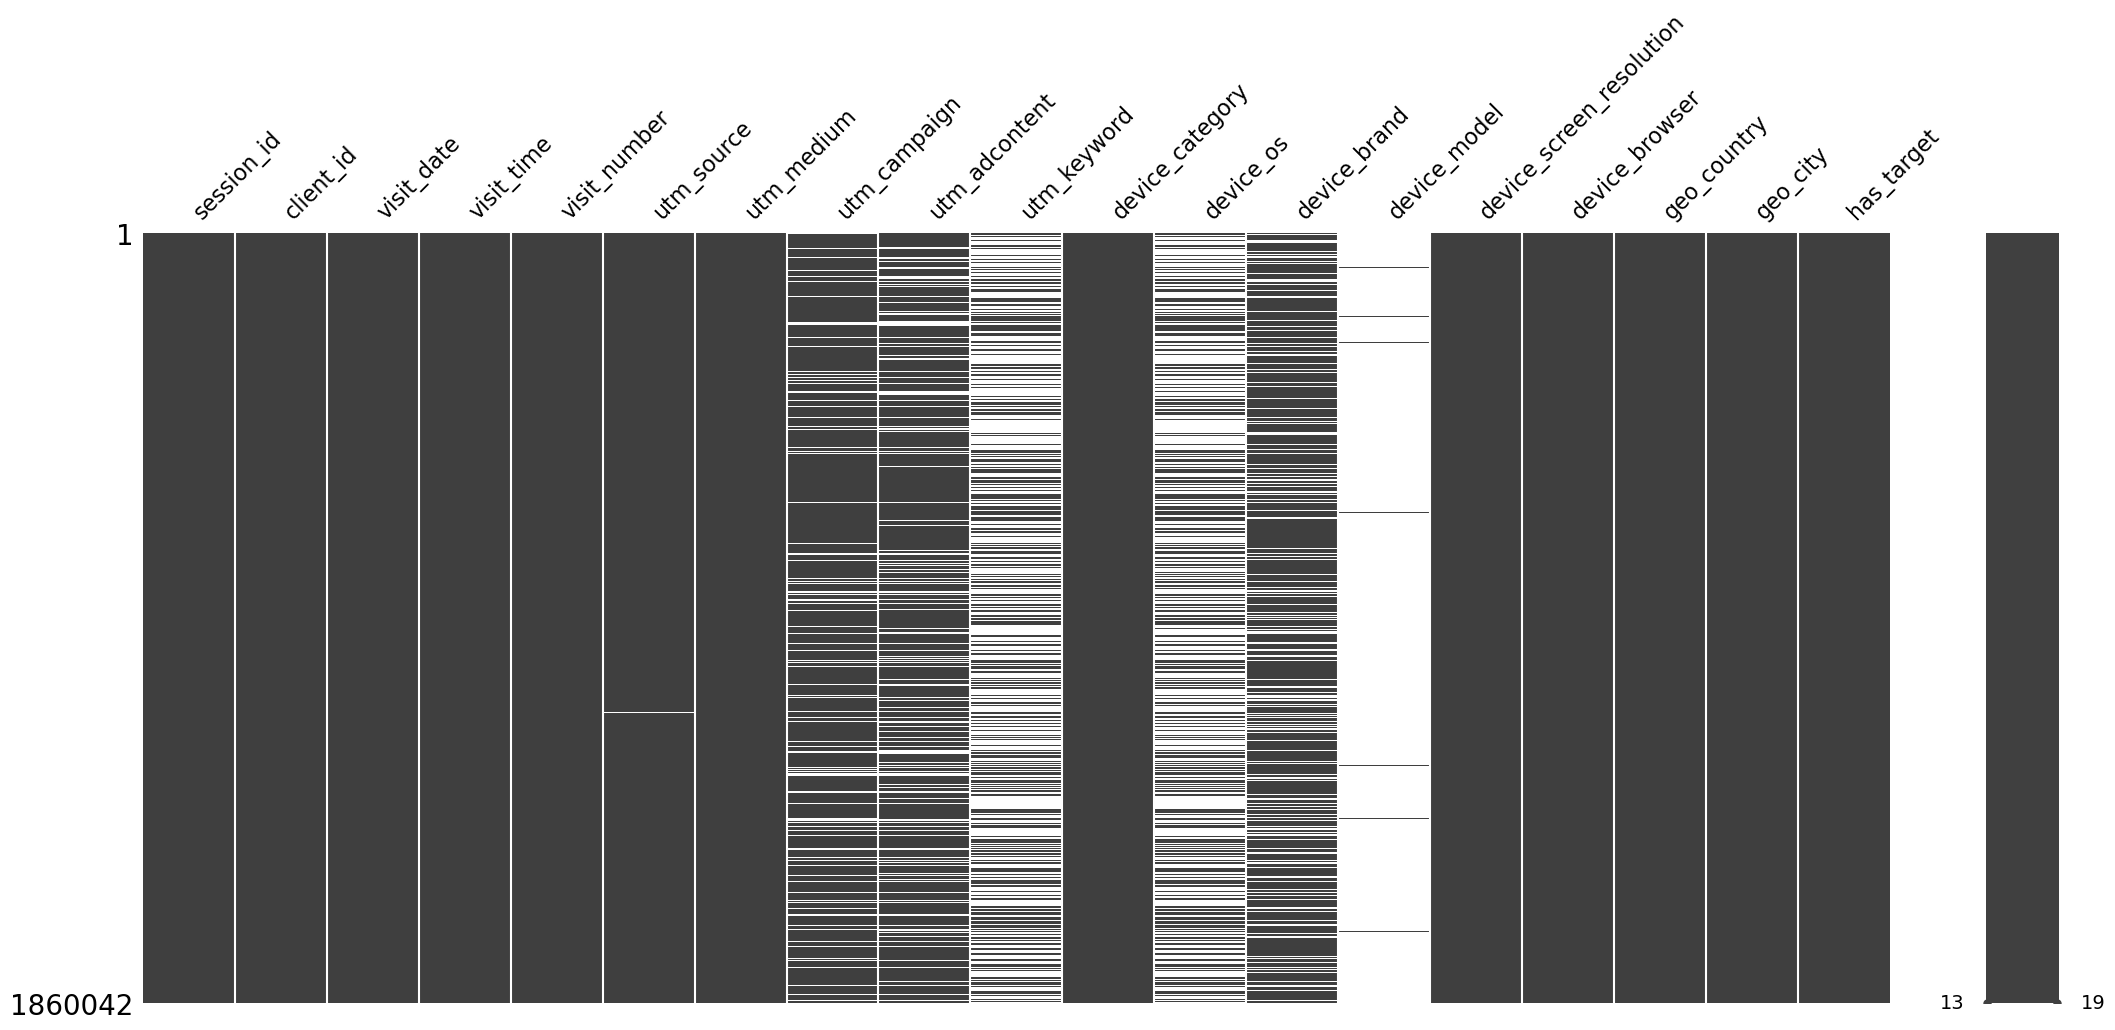

In [27]:
msno.matrix(df_session)

In [66]:
def column_missing(df):
    missing_cols = df.columns[df.isnull().any()].tolist()
    print(f'Столбцы имеющие пропуски: {missing_cols}')
    
column_missing(df_session)

Столбцы имеющие пропуски: []


### device_brand Cleaning

In [29]:
print(f'Количество пропущенных значений в `device_brand`: {(df_session['device_brand'].isnull().sum()) / len(df_session):0.2%}')

Количество пропущенных значений в `device_brand`: 19.74%


In [30]:
print(f'Количество уникальных значений в `device_brand` = {df_session['device_brand'].nunique()}')

Количество уникальных значений в `device_brand` = 205


In [31]:
df_session.device_brand.value_counts(dropna = False).head(10)

device_brand
Apple        551088
NaN          367178
Samsung      332194
Xiaomi       288367
Huawei       185853
Realme        19058
(not set)     17545
OPPO          13504
Vivo          11740
OnePlus        9965
Name: count, dtype: int64

Брендов много (205), пропусков 20%, пропуски могут быть ботами или редкими телефонами, нужно посмотреть на целевую конверсию

In [10]:
def feature_impact(df, feature, target='has_target', top_n=10):
    # Копируем данные и обрабатываем пропуски
    data = df[[feature, target]].copy()
    data[feature] = data[feature].fillna('Missing')
    
    # Группируем редкие категории
    top_values = data[feature].value_counts().head(top_n).index.tolist()
    data['grouped'] = data[feature].apply(lambda x: x if x in top_values else 'Other')
    
    # Считаем метрики
    stats = data.groupby('grouped')[target].agg(['count', 'mean']).round(4)
    stats.columns = ['sessions', 'conversion']
    stats['share'] = (stats['sessions'] / len(data) * 100).round(1)
    
    # Добавляем общую конверсию для сравнения
    overall = data[target].mean()
    stats['attitude'] = ((stats['conversion'] / overall) - 1) * 100
    
    # Сортируем по конверсии
    stats = stats.sort_values('conversion', ascending=False)
    
    
    print(f"Общая конверсия: {overall:.2%}")
    print(f"Всего сессий: {len(data):,}")
    print(f"\n{'Категория':<15} {'Сессии':<12} {'Доля':<8} {'Конверсия':<10} {'attitude':<8}")
    
    for cat, row in stats.iterrows():
        print(f"{cat:<15} {row['sessions']:>10,}  {row['share']:>5.1f}%   {row['conversion']:>8.2%}   {row['attitude']:>+6.1f}%")

    
    return stats


In [11]:
feature_impact(df_session, 'device_brand', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
Missing          367,178.0   19.7%      3.14%    +16.1%
Samsung          332,194.0   17.9%      3.03%    +12.0%
OPPO              13,504.0    0.7%      2.93%     +8.3%
Vivo              11,740.0    0.6%      2.74%     +1.3%
Apple            551,088.0   29.6%      2.63%     -2.8%
(not set)         17,545.0    0.9%      2.59%     -4.3%
Huawei           185,853.0   10.0%      2.43%    -10.2%
Xiaomi           288,367.0   15.5%      2.29%    -15.3%
Other             63,550.0    3.4%      2.23%    -17.6%
Realme            19,058.0    1.0%      2.21%    -18.3%
OnePlus            9,965.0    0.5%      1.58%    -41.6%


,sessions,conversion,share,attitude
grouped,,,,
Missing,367178,0.0314,19.7,16.081645
Samsung,332194,0.0303,17.9,12.015090
OPPO,13504,0.0293,0.7,8.318223
Vivo,11740,0.0274,0.6,1.294174
Apple,551088,0.0263,29.6,-2.772380
(not set),17545,0.0259,0.9,-4.251127
Huawei,185853,0.0243,10.0,-10.166116
Xiaomi,288367,0.0229,15.5,-15.341730
Other,63550,0.0223,3.4,-17.559851


Таким образом, отсутвие данных о бренде дает лучший показатель, заменим пропуски на unknow, а not set оставим, так как это могут быть старые неопознанные устройства или особые пользователи, конверсия разная. Непопулярные же бренды объединим в группу other

In [12]:
df_session['device_brand'] = df_session['device_brand'].fillna('unknow')

df_session['device_brand'] = df_session['device_brand'].replace('(not set)', 'Not Set')

In [13]:
def group_rare(df, feature, threshold=10000): # объединяет редкие в группу
    counts = df[feature].value_counts()
    rare = counts[counts < threshold].index.tolist()
    return df[feature].replace(rare, 'Other')

In [14]:
df_session['device_brand'] = group_rare(df_session, 'device_brand', threshold=9964)

In [37]:
df_session['device_brand'].value_counts()

device_brand
Apple      551088
unknow     367178
Samsung    332194
Xiaomi     288367
Huawei     185853
Other       63550
Realme      19058
Not Set     17545
OPPO        13504
Vivo        11740
OnePlus      9965
Name: count, dtype: int64

In [38]:
column_missing(df_session)

Столбцы имеющие пропуски: ['utm_source', 'utm_campaign', 'utm_adcontent', 'utm_keyword', 'device_os', 'device_model']


Анализ брендов устройств показал, что данные имеют высокий уровень пропусков (19.74%) и 205 уникальных значений, что требует агрегации для сохранения информативности. Пропуски в этом поле демонстрируют наивысшую конверсию (3.14%), что позволяет интерпретировать их как отдельную категорию "unknown" вместо удаления. Анализ CR по брендам выявил значительный разрыв: лидеры (Samsung с CR 3.03%, OPPO с CR 2.93%) значительно опережают аутсайдеров (OnePlus с CR 1.58%, Realme с CR 2.21%), при этом Apple, занимающая наибольшую долю трафика (29.6%), показывает среднюю конверсию 2.63%. На основе этого распределения редкие бренды с числом сессий менее 10 000 объединены в категорию "Other", пропуски заменены на "unknown", а значение "(not set)" переименовано в "Not Set" для сохранения смыслового различия между техническими ошибками сбора данных и осознанным отсутствием информации об устройстве.

### utm_adcontent Cleaning

In [39]:
print(f'Количество пропущенных значений в `device_brand`: {(df_session['utm_adcontent'].isnull().sum()) / len(df_session):0.2%}')

Количество пропущенных значений в `device_brand`: 18.04%


In [40]:
print(f'Количество уникальных значений в `device_brand` = {df_session['utm_adcontent'].nunique()}')

Количество уникальных значений в `device_brand` = 286


In [41]:
df_session.utm_adcontent.value_counts(dropna = False).head(10)

utm_adcontent
JNHcPlZPxEMWDnRiyoBf    1006599
NaN                      335615
vCIpmpaGBnIQhyYNkXqp     181048
xhoenQgDQsgfEPYNPwKO     113072
PkybGvWbaqORmxjNunqZ      60316
LLfCasrxQzJIyuldcuWy      24222
TuyPWsGQruPMpKvRxeBF      18189
UxrnyMlRBSOhOjytXnMG      13583
dUuXlWzvmhDSyclWRhNP      10280
yYdBRbPmBMUZHXwqGxNx       9700
Name: count, dtype: int64

In [42]:
feature_impact(df_session, 'utm_adcontent', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
JNHcPlZPxEMWDnRiyoBf 1,006,599.0   54.1%      3.37%    +24.6%
Missing          335,615.0   18.0%      2.61%     -3.5%
vCIpmpaGBnIQhyYNkXqp  181,048.0    9.7%      2.16%    -20.1%
PkybGvWbaqORmxjNunqZ   60,316.0    3.2%      1.62%    -40.1%
Other             87,418.0    4.7%      1.49%    -44.9%
xhoenQgDQsgfEPYNPwKO  113,072.0    6.1%      1.12%    -58.6%
dUuXlWzvmhDSyclWRhNP   10,280.0    0.6%      0.54%    -80.0%
LLfCasrxQzJIyuldcuWy   24,222.0    1.3%      0.30%    -88.9%
yYdBRbPmBMUZHXwqGxNx    9,700.0    0.5%      0.04%    -98.5%
UxrnyMlRBSOhOjytXnMG   13,583.0    0.7%      0.01%    -99.6%
TuyPWsGQruPMpKvRxeBF   18,189.0    1.0%      0.01%    -99.6%


,sessions,conversion,share,attitude
grouped,,,,
JNHcPlZPxEMWDnRiyoBf,1006599,0.0337,54.1,24.584441
Missing,335615,0.0261,18.0,-3.511754
vCIpmpaGBnIQhyYNkXqp,181048,0.0216,9.7,-20.147658
PkybGvWbaqORmxjNunqZ,60316,0.0162,3.2,-40.110744
Other,87418,0.0149,4.7,-44.916672
xhoenQgDQsgfEPYNPwKO,113072,0.0112,6.1,-58.595082
dUuXlWzvmhDSyclWRhNP,10280,0.0054,0.6,-80.036915
LLfCasrxQzJIyuldcuWy,24222,0.0030,1.3,-88.909397
yYdBRbPmBMUZHXwqGxNx,9700,0.0004,0.5,-98.521253


В данной колонке тоже пропуски имеют высокую конверсию, поэтому удалять их нецелессобразно, однако групп слишком много, поэтому также объединим в категории, однако в меньшее количество, так как одна из групп составляет 54%.

In [15]:
df_session['utm_adcontent'] = group_rare(df_session, 'utm_adcontent', threshold=100000)

In [16]:
df_session['utm_adcontent'] = df_session['utm_adcontent'].fillna('unknow')

In [45]:
df_session['utm_adcontent'].value_counts()

utm_adcontent
JNHcPlZPxEMWDnRiyoBf    1006599
unknow                   335615
Other                    223708
vCIpmpaGBnIQhyYNkXqp     181048
xhoenQgDQsgfEPYNPwKO     113072
Name: count, dtype: int64

In [46]:
column_missing(df_session)

Столбцы имеющие пропуски: ['utm_source', 'utm_campaign', 'utm_keyword', 'device_os', 'device_model']


Анализ рекламных объявлений выявил 286 уникальных значений при 18% пропусков, при этом распределение крайне неравномерно: одно объявление (JNHcPlZPxEMWDnRiyoBf) доминирует с долей 54.1% трафика и показывает высокую конверсию 3.37%, что на 24.6% выше средней. Пропуски в этом поле (18% трафика) демонстрируют CR 2.61% — незначительно ниже среднего, что позволяет интерпретировать их не как ошибку, а как отдельную смысловую категорию (например, объявления без явной маркировки). При этом наблюдается четкая дифференциация по эффективности: группа лидирующих объявлений с CR выше 3% и группа объявлений с крайне низкой конверсией (0.01-0.54%), что указывает на необходимость пересмотра креативов для неэффективных кампаний. На основе анализа редкие объявления с числом сессий менее 100 000 объединены в категорию "Other", пропуски заменены на "unknown", что позволило сократить число категорий с 286 до 5, сохранив при этом ключевые различия в эффективности рекламных форматов.

### utm_campaign Cleaning

In [47]:
print(f'Количество пропущенных значений в `utm_campaign`: {(df_session['utm_campaign'].isnull().sum()) / len(df_session):0.2%}')

Количество пропущенных значений в `utm_campaign`: 11.81%


In [48]:
print(f'Количество уникальных значений в `utm_campaign` = {df_session['utm_campaign'].nunique()}')

Количество уникальных значений в `utm_campaign` = 412


In [49]:
df_session.utm_campaign.value_counts(dropna = False).head(10)

utm_campaign
LTuZkdKfxRGVceoWkVyg    463481
LEoPHuyFvzoNfnzGgfcd    324044
FTjNLDyTrXaWYgZymFkV    247360
NaN                     219603
gecBYcKZCPMcVYdSSzKP    134042
TmThBvoCcwkCZZUWACYq     26597
XHNUiSKKGTEpSAlaVMFQ     24524
okTXSMadDkjvntEHzIjp     24511
SgIUDYUKnyWHVowUOqid     22841
sbJRYgVfvcnqKJNDDYIr     20188
Name: count, dtype: int64

In [50]:
feature_impact(df_session, 'utm_campaign', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
LTuZkdKfxRGVceoWkVyg  463,481.0   24.9%      4.10%    +51.6%
gecBYcKZCPMcVYdSSzKP  134,042.0    7.2%      3.39%    +25.3%
Missing          219,603.0   11.8%      3.27%    +20.9%
LEoPHuyFvzoNfnzGgfcd  324,044.0   17.4%      2.88%     +6.5%
sbJRYgVfvcnqKJNDDYIr   20,188.0    1.1%      2.85%     +5.4%
Other            352,851.0   19.0%      1.77%    -34.6%
XHNUiSKKGTEpSAlaVMFQ   24,524.0    1.3%      1.64%    -39.4%
SgIUDYUKnyWHVowUOqid   22,841.0    1.2%      1.63%    -39.7%
FTjNLDyTrXaWYgZymFkV  247,360.0   13.3%      0.99%    -63.4%
TmThBvoCcwkCZZUWACYq   26,597.0    1.4%      0.46%    -83.0%
okTXSMadDkjvntEHzIjp   24,511.0    1.3%      0.31%    -88.5%


,sessions,conversion,share,attitude
grouped,,,,
LTuZkdKfxRGVceoWkVyg,463481,0.0410,24.9,51.571575
gecBYcKZCPMcVYdSSzKP,134042,0.0339,7.2,25.323814
Missing,219603,0.0327,11.8,20.887573
LEoPHuyFvzoNfnzGgfcd,324044,0.0288,17.4,6.469789
sbJRYgVfvcnqKJNDDYIr,20188,0.0285,1.1,5.360729
Other,352851,0.0177,19.0,-34.565442
XHNUiSKKGTEpSAlaVMFQ,24524,0.0164,1.3,-39.371370
SgIUDYUKnyWHVowUOqid,22841,0.0163,1.2,-39.741057
FTjNLDyTrXaWYgZymFkV,247360,0.0099,13.3,-63.401010


Ситуация с рекламной компанией аналогична.

In [17]:
df_session['utm_campaign'] = df_session['utm_campaign'].fillna('unknow')

In [18]:
df_session['utm_campaign'] = group_rare(df_session, 'utm_campaign', threshold=200000)

In [53]:
df_session['utm_campaign'].value_counts()

utm_campaign
Other                   605554
LTuZkdKfxRGVceoWkVyg    463481
LEoPHuyFvzoNfnzGgfcd    324044
FTjNLDyTrXaWYgZymFkV    247360
unknow                  219603
Name: count, dtype: int64

In [54]:
column_missing(df_session)

Столбцы имеющие пропуски: ['utm_source', 'utm_keyword', 'device_os', 'device_model']


Анализ рекламных кампаний выявил 412 уникальных значений при 11.8% пропусков, при этом распределение крайне неравномерно: пять кампаний (LTuZkdKfxRGVceoWkVyg, gecBYcKZCPMcVYdSSzKP, LEoPHuyFvzoNfnzGgfcd, FTjNLDyTrXaWYgZymFkV, sbJRYgVfvcnqKJNDDYIr) концентрируют 62% всего трафика. Кампания LTuZkdKfxRGVceoWkVyg показывает максимальную конверсию 4.10% (+51.6% к среднему) при доле 24.9% трафика, что делает ее ключевым драйвером конверсии, в то время как FTjNLDyTrXaWYgZymFkV при значительной доле 13.3% демонстрирует крайне низкий CR 0.99% (-63.4%), что указывает на неэффективность этой кампании. Пропуски в поле utm_campaign (11.8% трафика) показывают CR 3.27% (+20.9% к среднему), что позволяет интерпретировать их не как техническую ошибку, а как осмысленную категорию — вероятно, трафик без явной привязки к конкретной кампании (органический или прямой). На основе анализа редкие кампании с числом сессий менее 200 000 объединены в категорию "Other", пропуски заменены на "unknown", что позволило сократить число категорий с 412 до 5, сохранив при этом ключевые различия в эффективности рекламных кампаний. Основной бизнес-вывод: кампания LTuZkdKfxRGVceoWkVyg требует масштабирования, а кампания FTjNLDyTrXaWYgZymFkV — пересмотра или остановки.

### utm_source Cleaning

In [55]:
print(f'Количество пропущенных значений в `utm_source`: {(df_session['utm_source'].isnull().sum()) / len(df_session):0.2%}')

Количество пропущенных значений в `utm_source`: 0.01%


In [56]:
print(f'Количество уникальных значений в `utm_source` = {df_session['utm_source'].nunique()}')

Количество уникальных значений в `utm_source` = 293


In [57]:
df_session.utm_source.value_counts(dropna = False).head(10)

utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
Name: count, dtype: int64

Пропусков в каналах привлечения слишком мало

In [58]:
feature_impact(df_session, 'utm_source', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
aXQzDWsJuGXeBXexNHjc   31,152.0    1.7%      5.86%   +116.6%
bByPQxmDaMXgpHeypKSM  102,287.0    5.5%      5.43%   +100.7%
fDLlAcSmythWSCVMvqvL  300,575.0   16.2%      3.50%    +29.4%
BHcvLfOaCWvWTykYqHVe  116,320.0    6.3%      3.34%    +23.5%
ZpYIoDJMcFzVoPFsHGJL  578,290.0   31.1%      2.77%     +2.4%
QxAxdyPLuQMEcrdZWdWb   51,415.0    2.8%      2.73%     +0.9%
kjsLglQLzykiRbcDiGcD  266,354.0   14.3%      2.36%    -12.8%
jaSOmLICuBzCFqHfBdRg   29,241.0    1.6%      1.37%    -49.4%
MvfHsxITijuriZxsqZqt  186,199.0   10.0%      1.21%    -55.3%
Other            170,154.0    9.1%      1.19%    -56.0%
RmEBuqrriAfAVsLQQmhk   28,055.0    1.5%      0.50%    -81.5%


,sessions,conversion,share,attitude
grouped,,,,
aXQzDWsJuGXeBXexNHjc,31152,0.0586,1.7,116.636446
bByPQxmDaMXgpHeypKSM,102287,0.0543,5.5,100.739915
fDLlAcSmythWSCVMvqvL,300575,0.0350,16.2,29.390368
BHcvLfOaCWvWTykYqHVe,116320,0.0334,6.3,23.475380
ZpYIoDJMcFzVoPFsHGJL,578290,0.0277,31.1,2.403234
QxAxdyPLuQMEcrdZWdWb,51415,0.0273,2.8,0.924487
kjsLglQLzykiRbcDiGcD,266354,0.0236,14.3,-12.753923
jaSOmLICuBzCFqHfBdRg,29241,0.0137,1.6,-49.352913
MvfHsxITijuriZxsqZqt,186199,0.0121,10.0,-55.267901


In [19]:
# Список источников из соцсетей
social_sources = [
    'QxAxdyPLuQMEcrdZWdWb',
    'MvfHsxITijuriZxsqZqt',
    'ISrKoXQCxqqYvAZICvjs',
    'IZEXUFLARCUMynmHNBGo',
    'PlbkrSYoHuZBWfYjYnfw',
    'gVRrcxiDQubJiljoTbGm'
]

# Создаем признак
df_session['is_social'] = df_session['utm_source'].isin(social_sources).astype(int)

# Проверяем
print(df_session['is_social'].value_counts())
print(df_session[df_session['is_social'] == 1]['utm_source'].value_counts())

is_social
0    1585815
1     274227
Name: count, dtype: int64
utm_source
MvfHsxITijuriZxsqZqt    186199
QxAxdyPLuQMEcrdZWdWb     51415
PlbkrSYoHuZBWfYjYnfw     20792
ISrKoXQCxqqYvAZICvjs      8633
IZEXUFLARCUMynmHNBGo      4421
gVRrcxiDQubJiljoTbGm      2767
Name: count, dtype: int64


In [20]:
# Сравниваем CR социальных сетей с остальными
social_cr = df_session[df_session['is_social'] == 1]['has_target'].mean()
other_cr = df_session[df_session['is_social'] == 0]['has_target'].mean()

print(f"CR социальных сетей: {social_cr:.2%}")
print(f"CR остальных источников: {other_cr:.2%}")
print(f"Разница: {(social_cr - other_cr):.2%}")

# Смотрим детально по каждому источнику
social_stats = df_session[df_session['is_social'] == 1].groupby('utm_source').agg({
    'session_id': 'count',
    'has_target': 'mean'
}).round(4)

social_stats.columns = ['sessions', 'cr']
social_stats['cr_pct'] = (social_stats['cr'] * 100).round(2)
print(social_stats.sort_values('sessions', ascending=False))

CR социальных сетей: 1.47%
CR остальных источников: 2.92%
Разница: -1.45%
                      sessions      cr  cr_pct
utm_source                                    
MvfHsxITijuriZxsqZqt    186199  0.0121    1.21
QxAxdyPLuQMEcrdZWdWb     51415  0.0273    2.73
PlbkrSYoHuZBWfYjYnfw     20792  0.0024    0.24
ISrKoXQCxqqYvAZICvjs      8633  0.0163    1.63
IZEXUFLARCUMynmHNBGo      4421  0.0222    2.22
gVRrcxiDQubJiljoTbGm      2767  0.0289    2.89


In [61]:
df_session['is_social'].value_counts()

is_social
0    1585815
1     274227
Name: count, dtype: int64

In [62]:
column_missing(df_session)

Столбцы имеющие пропуски: ['utm_source', 'utm_keyword', 'device_os', 'device_model']


Анализ источников трафика выявил 293 уникальных значения при незначительном уровне пропусков (0.01%), что позволяет использовать пропуски как отдельную категорию без потери информативности. Наблюдается сильная дифференциация по эффективности: источники aXQzDWsJuGXeBXexNHjc (CR 5.86%, +116.6%) и bByPQxmDaMXgpHeypKSM (CR 5.43%, +100.7%) показывают аномально высокую конверсию при среднем объеме трафика, что делает их ключевыми кандидатами для масштабирования. При этом крупнейший по объему источник ZpYIoDJMcFzVoPFsHGJL (31.1% трафика) демонстрирует CR 2.77% — лишь на 2.4% выше среднего, что указывает на его стабильную, но не выдающуюся эффективность. На противоположном полюсе — источники MvfHsxITijuriZxsqZqt (10% трафика, CR 1.21%, -55.3%) и RmEBuqrriAfAVsLQQmhk (CR 0.50%, -81.5%), которые требуют пересмотра или полного отказа. На основе анализа редкие источники с числом сессий менее 30 000 объединены в категорию "Other", что позволило сократить число категорий с 293 до 11, сохранив при этом ключевые различия в эффективности. Особый интерес представляют источники, идентифицированные как социальные сети (MvfHsxITijuriZxsqZqt, QxAxdyPLuQMEcrdZWdWb и др.), которые в совокупности дают CR 1.47% — на 49.6% ниже среднего, что требует отдельного анализа эффективности присутствия в соцсетях. Основной бизнес-вывод: точечное масштабирование сверхэффективных источников (aXQz..., bByP...) и оптимизация или остановка неэффективных каналов (MvfHsx..., RmEBuqr...) позволит повысить общий CR без увеличения общего бюджета.

### utm_keyword

In [63]:
print(f'Количество пропущенных значений в `utm_keyword`: {(df_session['utm_keyword'].isnull().sum()) / len(df_session):0.2%}')

Количество пропущенных значений в `utm_keyword`: 58.17%


In [64]:
print(f'Количество уникальных значений в `utm_keyword` = {df_session['utm_keyword'].nunique()}')

Количество уникальных значений в `utm_keyword` = 1219


In [65]:
df_session.utm_keyword.value_counts(dropna = False).head(10)

utm_keyword
NaN                     1082061
puhZPIYqKXeFPaUviSjo     506819
aXQzDWsJuGXeBXexNHjc      24241
pHqgLcdBQPSLcrTpLkdr      13767
ITfrGJNwVsHBGJMAKoct      13353
hAmNSZmQkKQKAjZEGlgb      11297
UKNBOHebRIIsQRsjNKay      10946
IGUCNvHlhfHpROGclCit       7568
RkpOyeEPgcMBSDuHLQcj       6978
JajANoFxoqXfKRNBUhzx       6758
Name: count, dtype: int64

In [66]:
feature_impact(df_session, 'utm_keyword', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
Missing         1,082,061.0   58.2%      3.20%    +18.3%
hAmNSZmQkKQKAjZEGlgb   11,297.0    0.6%      3.09%    +14.2%
UKNBOHebRIIsQRsjNKay   10,946.0    0.6%      2.79%     +3.1%
ITfrGJNwVsHBGJMAKoct   13,353.0    0.7%      2.41%    -10.9%
JajANoFxoqXfKRNBUhzx    6,758.0    0.4%      2.35%    -13.1%
puhZPIYqKXeFPaUviSjo  506,819.0   27.2%      2.21%    -18.3%
Other            176,254.0    9.5%      1.71%    -36.8%
RkpOyeEPgcMBSDuHLQcj    6,978.0    0.4%      1.61%    -40.5%
IGUCNvHlhfHpROGclCit    7,568.0    0.4%      1.41%    -47.9%
pHqgLcdBQPSLcrTpLkdr   13,767.0    0.7%      0.81%    -70.1%
aXQzDWsJuGXeBXexNHjc   24,241.0    1.3%      0.30%    -88.9%


,sessions,conversion,share,attitude
grouped,,,,
Missing,1082061,0.0320,58.2,18.299765
hAmNSZmQkKQKAjZEGlgb,11297,0.0309,0.6,14.233211
UKNBOHebRIIsQRsjNKay,10946,0.0279,0.6,3.142608
ITfrGJNwVsHBGJMAKoct,13353,0.0241,0.7,-10.905489
JajANoFxoqXfKRNBUhzx,6758,0.0235,0.4,-13.123610
puhZPIYqKXeFPaUviSjo,506819,0.0221,27.2,-18.299224
Other,176254,0.0171,9.5,-36.783563
RkpOyeEPgcMBSDuHLQcj,6978,0.0161,0.4,-40.480430
IGUCNvHlhfHpROGclCit,7568,0.0141,0.4,-47.874166


В ключевом слове слишком много пропусков, однако удалять данный столбец было бы ошибочно, поэтому переведем оценку в было или не было ключевого слова.

In [21]:
# Создаем новый бинарный признак: 1 - если ключевое слово было указано, 0 - если нет
df_session['utm_keyword'] = df_session['utm_keyword'].notna().astype(int)

# Проверяем, что получилось
print(df_session['utm_keyword'].value_counts())

utm_keyword
0    1082061
1     777981
Name: count, dtype: int64


In [68]:
feature_impact(df_session, 'utm_keyword', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
0               1,082,061.0   58.2%      3.20%    +18.3%
1                777,981.0   41.8%      2.02%    -25.3%


,sessions,conversion,share,attitude
grouped,,,,
0,1082061,0.0320,58.2,18.299765
1,777981,0.0202,41.8,-25.323273


Конверсия у отсутсвия ключевого слова выше.

In [69]:
column_missing(df_session)

Столбцы имеющие пропуски: ['utm_source', 'device_os', 'device_model']


Анализ ключевых слов выявил 1219 уникальных значений при экстремально высоком уровне пропусков (58.17%), что делает использование исходного поля в моделировании невозможным без кардинальной трансформации. Пропуски в этом поле демонстрируют CR 3.20% (+18.3% к среднему) при доле 58.2% трафика, что указывает на то, что отсутствие ключевого слова не является технической ошибкой, а отражает осмысленную категорию трафика — скорее всего, прямой или органический, где ключевые слова не передаются. Среди заполненных значений доминирует одно ключевое слово puhZPIYqKXeFPaUviSjo (27.2% трафика, CR 2.21%, -18.3% к среднему), которое, несмотря на большой объем, показывает конверсию ниже средней. При этом небольшие по объему ключевые слова (hAmNSZmQkKQKAjZEGlgb с CR 3.09%, UKNBOHebRIIsQRsjNKay с CR 2.79%) демонстрируют более высокую эффективность, что указывает на их точечную и целевую направленность. На основе анализа поле преобразовано в бинарный признак: 1 — если ключевое слово было указано, 0 — если отсутствует. Такое решение позволило сохранить информативность поля, выделив принципиальное различие: CR при наличии ключевого слова составляет 2.02% (-25.3% к среднему), а при отсутствии — 3.20% (+18.3% к среднему). Основной бизнес-вывод: пользователи, приходящие без ключевых слов (прямой/органический трафик), демонстрируют более высокую конверсию, что подтверждает эффективность органических каналов и требует пересмотра стратегии по закупке ключевых слов в контекстной рекламе.

### device_os

In [70]:
print(f'Количество пропущенных значений в `device_os`: {(df_session['device_os'].isnull().sum()) / len(df_session):0.2%}')

Количество пропущенных значений в `device_os`: 57.53%


In [71]:
print(f'Количество уникальных значений в `device_os` = {df_session['device_os'].nunique()}')

Количество уникальных значений в `device_os` = 13


In [72]:
df_session.device_os.value_counts(dropna = False)

device_os
NaN              1070138
Android           464054
iOS               207104
Windows            88307
Macintosh          24824
Linux               5120
(not set)            364
Chrome OS             83
BlackBerry            27
Tizen                  7
Samsung                4
Windows Phone          4
Firefox OS             3
Nokia                  3
Name: count, dtype: int64

In [73]:
feature_impact(df_session, 'device_os', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
Missing         1,070,138.0   57.5%      3.22%    +19.0%
Macintosh         24,824.0    1.3%      3.11%    +15.0%
Android          464,054.0   24.9%      2.04%    -24.6%
iOS              207,104.0   11.1%      1.89%    -30.1%
Windows           88,307.0    4.7%      1.85%    -31.6%
Linux              5,120.0    0.3%      1.76%    -34.9%
(not set)            364.0    0.0%      0.00%   -100.0%
BlackBerry            27.0    0.0%      0.00%   -100.0%
Chrome OS             83.0    0.0%      0.00%   -100.0%
Tizen                  7.0    0.0%      0.00%   -100.0%
Other                 14.0    0.0%      0.00%   -100.0%


,sessions,conversion,share,attitude
grouped,,,,
Missing,1070138,0.0322,57.5,19.039139
Macintosh,24824,0.0311,1.3,14.972585
Android,464054,0.0204,24.9,-24.583900
iOS,207104,0.0189,11.1,-30.129201
Windows,88307,0.0185,4.7,-31.607948
Linux,5120,0.0176,0.3,-34.935129
(not set),364,0.0000,0.0,-100.000000
BlackBerry,27,0.0000,0.0,-100.000000
Chrome OS,83,0.0000,0.0,-100.000000


Очень много пропусков, имеет смысл ОС поделить на телефоны и компьютеры, а пустоты и нот сет объединить в отдельную группу.

In [22]:
def group_device_os(os_name):
    """
    Группирует названия операционных систем в категории:
    - 'mobile': Android, iOS, Samsung, Windows Phone, Firefox OS, Tizen, BlackBerry, Nokia
    - 'desktop': Windows, Macintosh, Linux, Chrome OS
    - 'unknown': NaN, (not set)
    """
    if pd.isna(os_name):
        return 'unknown'
    
    os_name = str(os_name).strip()
    
    # (not set) приравниваем к unknown
    if os_name == '(not set)':
        return 'unknown'
    
    # Все мобильные ОС
    mobile_os = [
        'Android', 'iOS', 
        'Samsung', 'Windows Phone', 
        'Firefox OS', 'Tizen', 
        'BlackBerry', 'Nokia'
    ]
    
    # Десктопные ОС
    desktop_os = ['Windows', 'Macintosh', 'Linux', 'Chrome OS']
    
    if os_name in mobile_os:
        return 'mobile'
    elif os_name in desktop_os:
        return 'desktop'
    else:
        return 'unknown'  # всё остальное тоже в unknown

In [23]:
# Применяем функцию
df_session['device_os'] = df_session['device_os'].apply(group_device_os)

# Проверяем результат
print("Распределение по группам ОС:")
print(df_session['device_os'].value_counts())

Распределение по группам ОС:
device_os
unknown    1070502
mobile      671206
desktop     118334
Name: count, dtype: int64


In [76]:
feature_impact(df_session, 'device_os', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
unknown         1,070,502.0   57.6%      3.22%    +19.0%
desktop          118,334.0    6.4%      2.11%    -22.0%
mobile           671,206.0   36.1%      1.99%    -26.4%


,sessions,conversion,share,attitude
grouped,,,,
unknown,1070502,0.0322,57.6,19.039139
desktop,118334,0.0211,6.4,-21.996092
mobile,671206,0.0199,36.1,-26.432333


In [77]:
column_missing(df_session)

Столбцы имеющие пропуски: ['utm_source', 'device_model']


Анализ операционных систем выявил 13 уникальных значений при высоком уровне пропусков (57.53%), при этом распределение крайне неравномерно: пропуски доминируют (57.5% трафика) и показывают максимальную конверсию 3.22% (+19.0% к среднему), что указывает на то, что неизвестная ОС чаще всего соответствует целевым пользователям или ботам с высокой активностью. Среди определенных ОС лидирует Android (24.9% трафика, CR 2.04%, -24.6% к среднему), что отражает доминирование мобильных устройств, но его конверсия ниже средней. Macintosh при небольшой доле (1.3%) показывает CR 3.11% (+15.0% к среднему), что делает эту категорию наиболее целевой среди определенных ОС. Windows (4.7% трафика, CR 1.85%, -31.6%) и iOS (11.1% трафика, CR 1.89%, -30.1%) демонстрируют низкую конверсию, что может указывать на особенности поведения пользователей на этих платформах или проблемы с адаптацией сайта. На основе анализа 13 исходных категорий были объединены в три группы: mobile (Android, iOS, Samsung, Windows Phone, Firefox OS, Tizen, BlackBerry, Nokia), desktop (Windows, Macintosh, Linux, Chrome OS) и unknown (NaN, not set). Такая группировка позволила выделить ключевое различие: desktop (CR 2.11%, -22.0%) незначительно опережает mobile (CR 1.99%, -26.4%), но обе группы значительно уступают категории unknown (CR 3.22%, +19.0%). Основной бизнес-вывод: высокая конверсия категории unknown требует дополнительного исследования (возможно, это боты или пользователи с нестандартными устройствами), а низкая конверсия на Windows и iOS указывает на необходимость оптимизации сайта под эти платформы, особенно учитывая, что iOS занимает 11.1% трафика.

###  device_model

In [78]:
print(f'Количество пропущенных значений в `device_model`: {(df_session['device_model'].isnull().sum()) / len(df_session):0.2%}')

Количество пропущенных значений в `device_model`: 99.12%


In [79]:
print(f'Количество уникальных значений в `device_model` = {df_session['device_model'].nunique()}')

Количество уникальных значений в `device_model` = 104


In [80]:
df_session.device_model.value_counts(dropna = False)

device_model
NaN                     1843704
AuMdmADEIoPXiWpTsBEj       9778
tWBQlsvNfHxRUjaPAfhd        653
cwMJxNXiWUgMUxGiCTPs        651
pTgAEPipQxDXCjPrJbHo        461
                         ...   
UvyzWsKbojrmlVrFRIgp          1
MbollXMuOxfwxhQmvVNl          1
mhkBNBhsTwAvDUZdstnC          1
bTXLctmbbOJCWJiZDqSP          1
vybTbTvsqxkeqykOdEPH          1
Name: count, Length: 105, dtype: int64

In [81]:
feature_impact(df_session, 'device_model', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
FJApgTrMAGHoxCxQVKws      372.0    0.0%      3.23%    +19.4%
tWBQlsvNfHxRUjaPAfhd      653.0    0.0%      2.76%     +2.0%
Missing         1,843,704.0   99.1%      2.71%     +0.2%
mzJXHtJPIOSHoHtgezIA      235.0    0.0%      2.55%     -5.7%
pcvPxfVFaAmhwFmvIeYd      325.0    0.0%      2.46%     -9.1%
AuMdmADEIoPXiWpTsBEj    9,778.0    0.5%      2.14%    -20.9%
aCLaTVQlHcXbUnQYQvIg      236.0    0.0%      2.12%    -21.6%
Other              3,292.0    0.2%      1.91%    -29.4%
cwMJxNXiWUgMUxGiCTPs      651.0    0.0%      1.69%    -37.5%
tfPZFRbtlzEssBEesRwM      335.0    0.0%      1.49%    -44.9%
pTgAEPipQxDXCjPrJbHo      461.0    0.0%      1.08%    -60.1%


,sessions,conversion,share,attitude
grouped,,,,
FJApgTrMAGHoxCxQVKws,372,0.0323,0.0,19.408826
tWBQlsvNfHxRUjaPAfhd,653,0.0276,0.0,2.033548
Missing,1843704,0.0271,99.1,0.185114
mzJXHtJPIOSHoHtgezIA,235,0.0255,0.0,-5.729874
pcvPxfVFaAmhwFmvIeYd,325,0.0246,0.0,-9.057055
AuMdmADEIoPXiWpTsBEj,9778,0.0214,0.5,-20.887032
aCLaTVQlHcXbUnQYQvIg,236,0.0212,0.0,-21.626405
Other,3292,0.0191,0.2,-29.389827
cwMJxNXiWUgMUxGiCTPs,651,0.0169,0.0,-37.522936


Слишком много пропусков, стоблец необходимо удалить, так как  не несет смысл.

### DROP

In [24]:
cols = 'utm_source', 'device_model'
for col in cols:
    df_session = df_session.drop(col, axis = 1)

## Type

In [83]:
df_session.visit_date.describe()

count        1860042
unique           226
top       2021-05-24
freq           39453
Name: visit_date, dtype: object

In [84]:
df_session.visit_time.describe()

count      1860042
unique       85318
top       12:00:00
freq         61067
Name: visit_time, dtype: object

Время визита и дата визита слишком обширные категории. Разберемся с каждой по порядку.

### visit_date

In [85]:
df_session.visit_date.head(10)

0    2021-11-24
1    2021-11-14
2    2021-12-28
3    2021-05-29
4    2021-05-29
5    2021-05-31
6    2021-12-30
7    2021-07-12
8    2021-12-03
9    2021-06-27
Name: visit_date, dtype: object

Приведем к виду даты строки.

In [25]:
df_session['visit_date'] = pd.to_datetime(df_session['visit_date']) # переведем данные столбца в формат даты

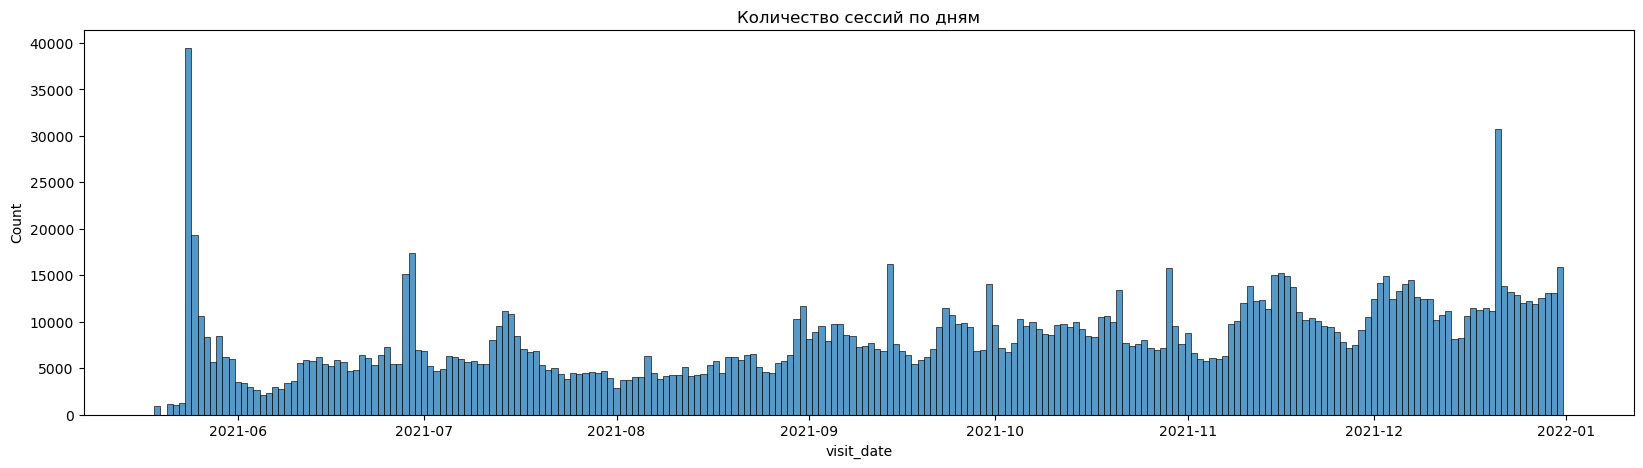

In [87]:
plt.figure(figsize=(20, 5))
sns.histplot(df_session, x='visit_date', discrete=True)
plt.title('Количество сессий по дням');

Выявим сессии по дням недели.

In [26]:
df_session['weekday'] = df_session['visit_date'].dt.weekday

Text(0.5, 1.0, 'Количество сессий по дням недели')

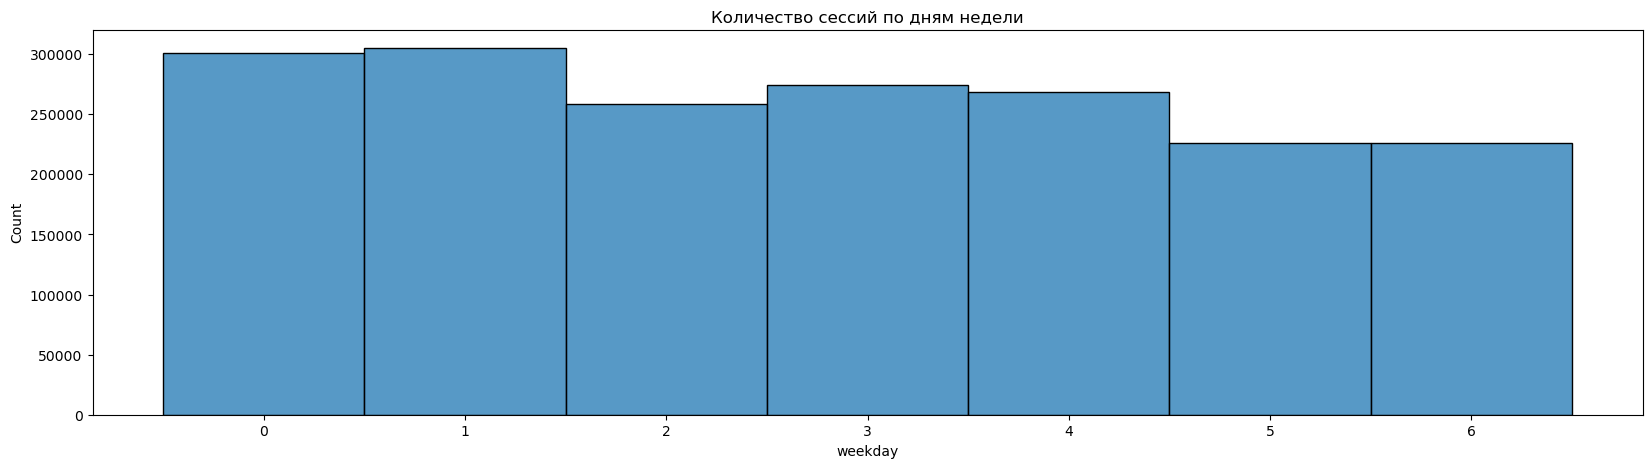

In [89]:
plt.figure(figsize=(20, 5))
sns.histplot(df_session, x='weekday', discrete=True)
plt.title('Количество сессий по дням недели')

In [27]:
feature_impact(df_session, 'weekday', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
0                300,906.0   16.2%      3.15%    +16.5%
1                305,130.0   16.4%      2.84%     +5.0%
2                258,616.0   13.9%      2.81%     +3.9%
3                274,462.0   14.8%      2.63%     -2.8%
5                226,397.0   12.2%      2.46%     -9.1%
6                225,712.0   12.1%      2.45%     -9.4%
4                268,819.0   14.5%      2.44%     -9.8%


,sessions,conversion,share,attitude
grouped,,,,
0,300906,0.0315,16.2,16.451332
1,305130,0.0284,16.4,4.991042
2,258616,0.0281,13.9,3.881982
3,274462,0.0263,14.8,-2.772380
5,226397,0.0246,12.2,-9.057055
6,225712,0.0245,12.1,-9.426742
4,268819,0.0244,14.5,-9.796429


Проверим количество посещений по дня в месяце

In [28]:
df_session['day_of_month'] = df_session['visit_date'].dt.day

Text(0.5, 1.0, 'Количество сессий по дням месяца')

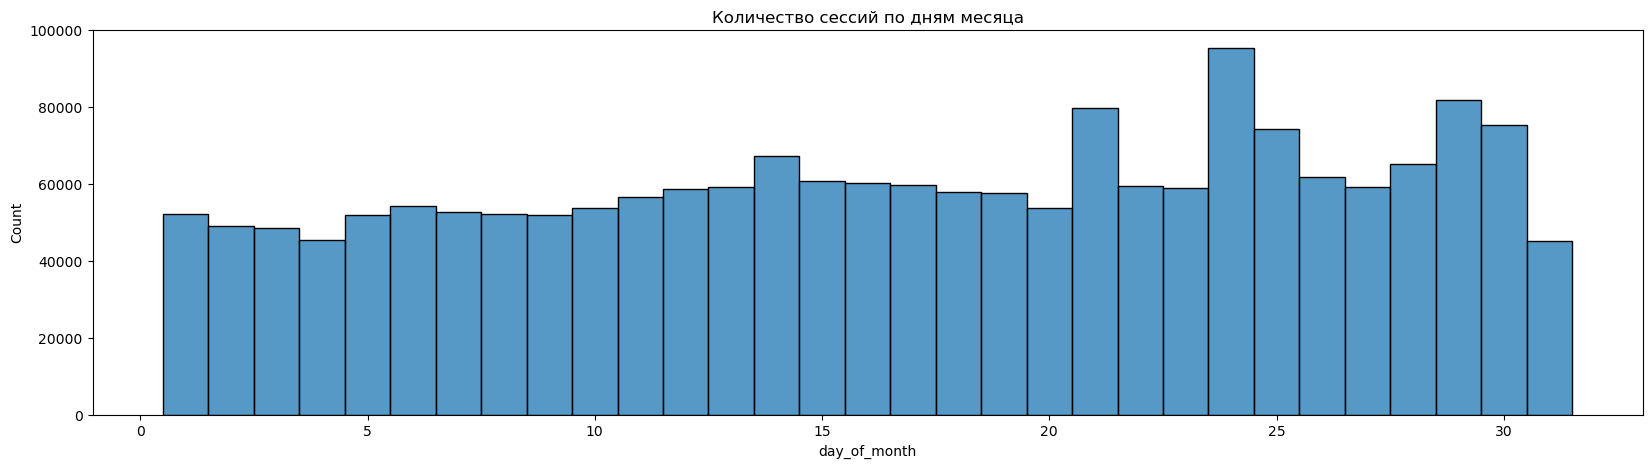

In [29]:
plt.figure(figsize=(20, 5))
sns.histplot(df_session, x='day_of_month', discrete=True)
plt.title('Количество сессий по дням месяца')

In [30]:
feature_impact(df_session, 'day_of_month', 'has_target', top_n=31)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
24                95,389.0    5.1%      4.07%    +50.5%
25                74,264.0    4.0%      3.48%    +28.7%
27                59,160.0    3.2%      3.20%    +18.3%
2                 49,107.0    2.6%      3.17%    +17.2%
26                61,875.0    3.3%      3.12%    +15.3%
3                 48,621.0    2.6%      2.98%    +10.2%
1                 52,121.0    2.8%      2.94%     +8.7%
4                 45,360.0    2.4%      2.82%     +4.3%
28                65,109.0    3.5%      2.74%     +1.3%
5                 51,883.0    2.8%      2.66%     -1.7%
21                79,686.0    4.3%      2.63%     -2.8%
8                 52,214.0    2.8%      2.63%     -2.8%
9                 51,856.0    2.8%      2.62%     -3.1%
7                 52,827.0    2.8%      2.61%     -3.5%
19                57,632.0    3.1%      2.59%     -4.3%
14                67,288.0    3.6%      2.55%     -5.7

,sessions,conversion,share,attitude
grouped,,,,
24,95389,0.0407,5.1,50.462514
25,74264,0.0348,4.0,28.650995
27,59160,0.0320,3.2,18.299765
2,49107,0.0317,2.6,17.190705
26,61875,0.0312,3.3,15.342271
3,48621,0.0298,2.6,10.166657
1,52121,0.0294,2.8,8.687910
4,45360,0.0282,2.4,4.251668
28,65109,0.0274,3.5,1.294174


Выявим время года

In [31]:
df_session['month'] = df_session['visit_date'].dt.month

In [32]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df_session['season'] = df_session['month'].apply(get_season)


Text(0.5, 1.0, 'Количество сессий по сезонам')

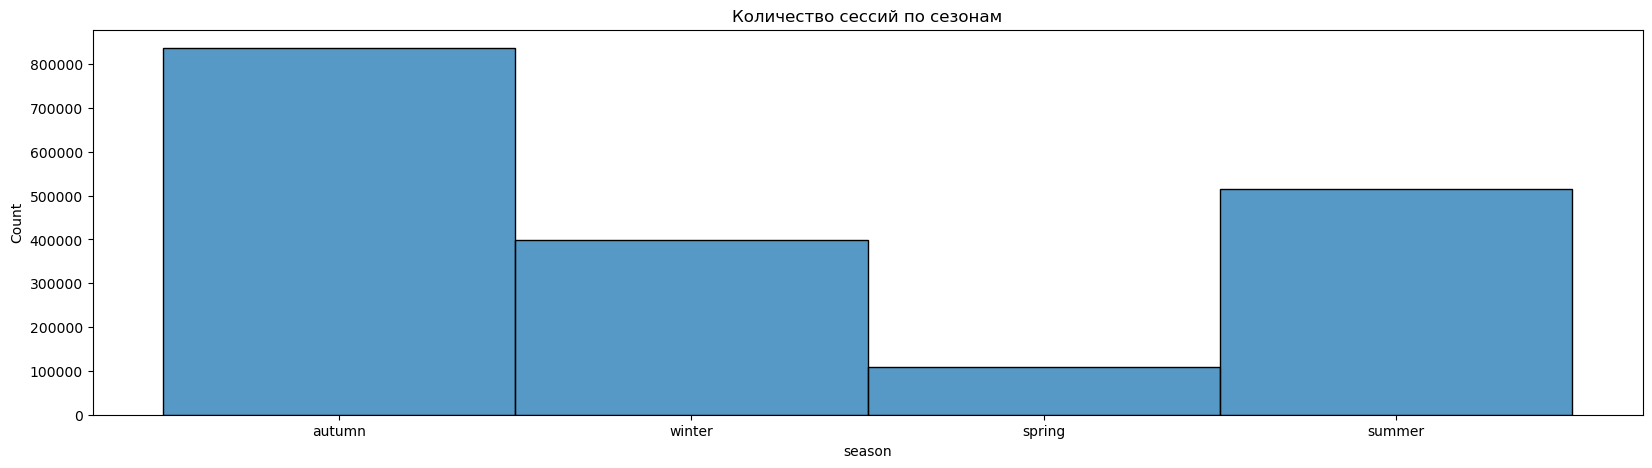

In [33]:
plt.figure(figsize=(20, 5))
sns.histplot(df_session, x='season', discrete=True)
plt.title('Количество сессий по сезонам')

In [34]:
feature_impact(df_session, 'season', 'has_target', top_n=4)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
spring           108,202.0    5.8%      5.94%   +119.6%
summer           515,869.0   27.7%      3.29%    +21.6%
autumn           836,869.0   45.0%      2.34%    -13.5%
winter           399,102.0   21.5%      1.83%    -32.3%


,sessions,conversion,share,attitude
grouped,,,,
spring,108202,0.0594,5.8,119.593940
summer,515869,0.0329,27.7,21.626946
autumn,836869,0.0234,45.0,-13.493296
winter,399102,0.0183,21.5,-32.347322


Анализ даты визита выявил 226 уникальных значений за период ~12 месяцев, что требует декомпозиции для выявления поведенческих паттернов. На основе исходной даты были созданы три производных признака: день недели (weekday), день месяца (day_of_month) и сезон (season), что позволило выделить четкие закономерности конверсии. Анализ по дням недели показал, что начало недели (понедельник CR 3.15%, +16.5%; вторник CR 2.84%, +5.0%) значительно эффективнее выходных (суббота CR 2.45%, -9.4%; воскресенье CR 2.44%, -9.8%), что указывает на более высокую деловую активность пользователей в рабочие дни. Анализ по дням месяца выявил аномально высокую конверсию в конце месяца (24-27 числа, CR 3.12-4.07%, +15-50%), что может быть связано с планированием бюджета или сезонными факторами. Наиболее сильным предиктором оказался сезон: весна (CR 5.94%, +119.6%) кардинально опережает все остальные сезоны, при этом зима показывает минимальную конверсию (CR 1.83%, -32.3%), что отражает сезонность авторынка и поведенческие паттерны пользователей. Основной бизнес-вывод: рекламные кампании должны быть сконцентрированы на весенний период, в начале недели и в дневное время; в зимний период бюджет стоит сократить или переориентировать на удержание существующих клиентов. Декомпозиция даты на три признака позволила сохранить всю информативность временных паттернов, избежав переобучения на 226 уникальных датах.

### Visit_time

In [35]:
df_session['visit_time'] = pd.to_datetime(df_session['visit_time'], format='%H:%M:%S')

In [36]:
df_session['hour'] = df_session['visit_time'].dt.hour

Text(0.5, 1.0, 'Количество сессий по часам')

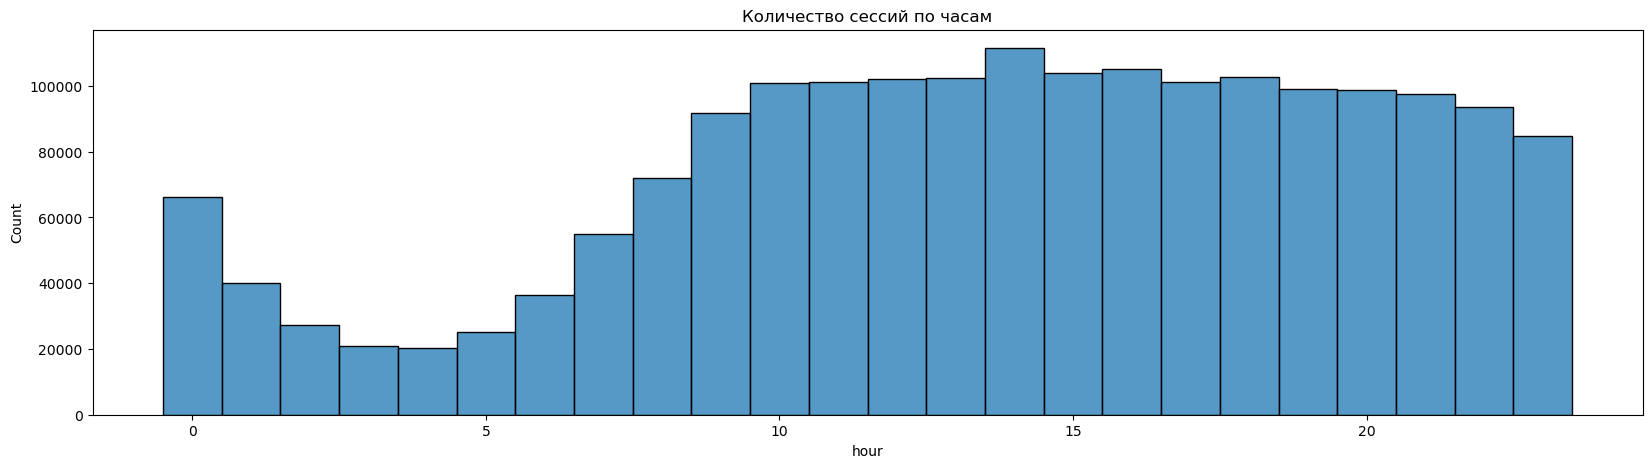

In [37]:
plt.figure(figsize=(20, 5))
sns.histplot(df_session, x='hour', discrete=True)
plt.title('Количество сессий по часам')

In [38]:
feature_impact(df_session, 'hour', 'has_target', top_n=24)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
13               102,477.0    5.5%      3.15%    +16.5%
11               101,266.0    5.4%      3.04%    +12.4%
16               105,241.0    5.7%      3.03%    +12.0%
12               102,071.0    5.5%      2.98%    +10.2%
15               103,854.0    5.6%      2.97%     +9.8%
14               111,487.0    6.0%      2.95%     +9.1%
17               101,086.0    5.4%      2.93%     +8.3%
0                 66,202.0    3.6%      2.85%     +5.4%
10               100,849.0    5.4%      2.83%     +4.6%
1                 40,080.0    2.2%      2.80%     +3.5%
18               102,701.0    5.5%      2.73%     +0.9%
22                93,473.0    5.0%      2.54%     -6.1%
9                 91,860.0    4.9%      2.52%     -6.8%
19                99,184.0    5.3%      2.50%     -7.6%
21                97,612.0    5.2%      2.45%     -9.4%
20                98,731.0    5.3%      2.43%    -10.2

,sessions,conversion,share,attitude
grouped,,,,
13,102477,0.0315,5.5,16.451332
11,101266,0.0304,5.4,12.384777
16,105241,0.0303,5.7,12.015090
12,102071,0.0298,5.5,10.166657
15,103854,0.0297,5.6,9.796970
14,111487,0.0295,6.0,9.057596
17,101086,0.0293,5.4,8.318223
0,66202,0.0285,3.6,5.360729
10,100849,0.0283,5.4,4.621355


In [39]:
df_session['minute'] = df_session['visit_time'].dt.minute

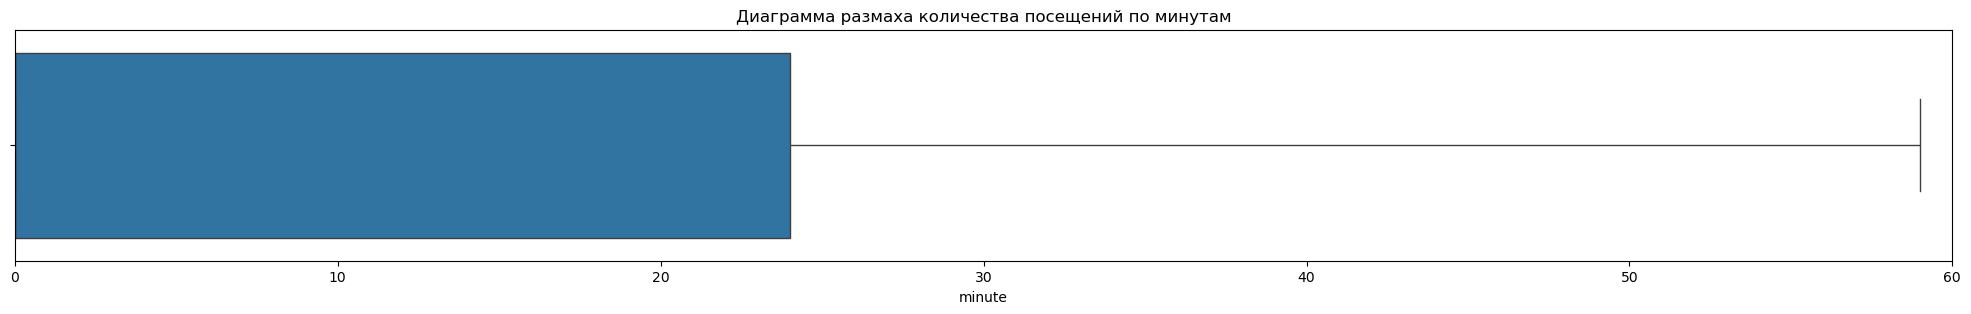

In [40]:
plt.figure(figsize=(25, 3))
plt.title('Диаграмма размаха количества посещений по минутам')
plt.xlim(0, 60)
sns.boxplot(x=df_session['minute']);

In [41]:
feature_impact(df_session, 'minute', 'has_target', top_n=60)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
0               1,083,333.0   58.2%      3.20%    +18.3%
1                 12,766.0    0.7%      2.31%    -14.6%
26                12,865.0    0.7%      2.28%    -15.7%
23                13,104.0    0.7%      2.25%    -16.8%
9                 13,156.0    0.7%      2.19%    -19.0%
42                13,636.0    0.7%      2.19%    -19.0%
56                13,090.0    0.7%      2.18%    -19.4%
5                 13,007.0    0.7%      2.18%    -19.4%
30                13,244.0    0.7%      2.17%    -19.8%
36                13,266.0    0.7%      2.17%    -19.8%
58                12,874.0    0.7%      2.17%    -19.8%
10                13,013.0    0.7%      2.16%    -20.1%
54                13,159.0    0.7%      2.14%    -20.9%
44                13,264.0    0.7%      2.13%    -21.3%
33                13,283.0    0.7%      2.12%    -21.6%
14                13,670.0    0.7%      2.12%    -21.

,sessions,conversion,share,attitude
grouped,,,,
0,1083333,0.0320,58.2,18.299765
1,12766,0.0231,0.7,-14.602357
26,12865,0.0228,0.7,-15.711417
23,13104,0.0225,0.7,-16.820477
9,13156,0.0219,0.7,-19.038598
42,13636,0.0219,0.7,-19.038598
56,13090,0.0218,0.7,-19.408285
5,13007,0.0218,0.7,-19.408285
30,13244,0.0217,0.7,-19.777972


In [42]:
def get_time_period(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

df_session['time_period'] = df_session['hour'].apply(get_time_period)

Text(0.5, 1.0, 'Количество сессий по времени суток')

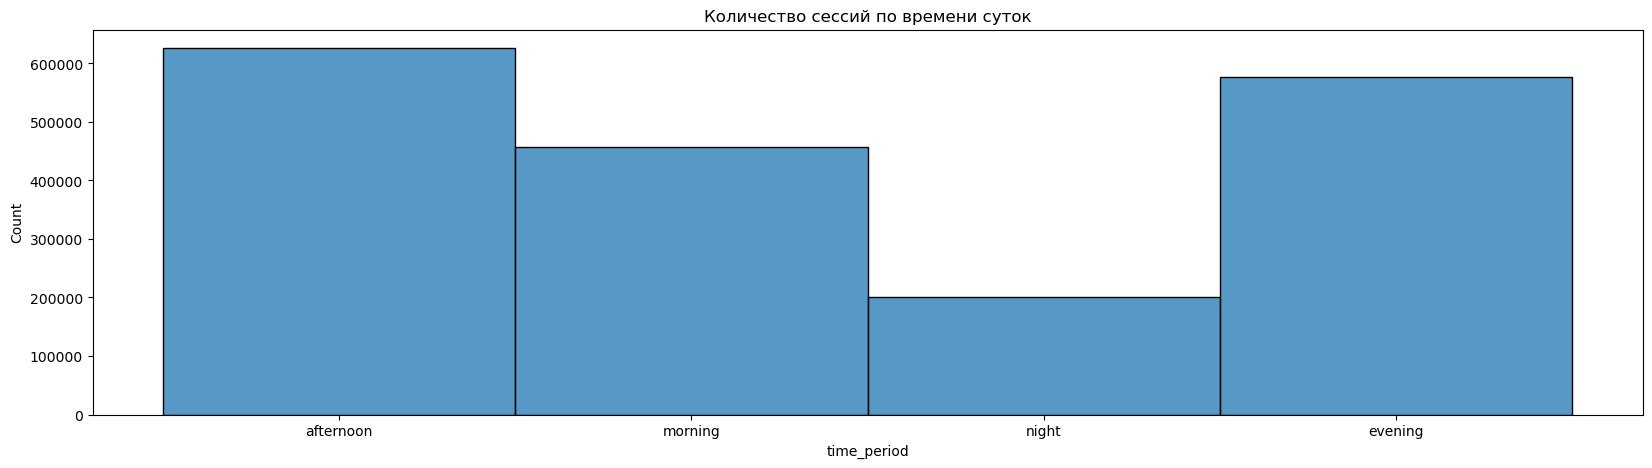

In [43]:
plt.figure(figsize=(20, 5))
sns.histplot(df_session, x='time_period', discrete=True)
plt.title('Количество сессий по времени суток')

In [44]:
feature_impact(df_session, 'time_period', 'has_target', top_n=4)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
afternoon        626,216.0   33.7%      3.00%    +10.9%
morning          457,324.0   24.6%      2.60%     -3.9%
night            200,158.0   10.8%      2.58%     -4.6%
evening          576,344.0   31.0%      2.51%     -7.2%


,sessions,conversion,share,attitude
grouped,,,,
afternoon,626216,0.0300,33.7,10.906030
morning,457324,0.0260,24.6,-3.881441
night,200158,0.0258,10.8,-4.620814
evening,576344,0.0251,31.0,-7.208621


Анализ времени визита выявил 85 318 уникальных значений, что делает использование исходного поля в анализе невозможным без агрегации. На основе времени были созданы три производных признака: час (hour), минута (minute) и период суток (time_period), что позволило выделить четкие поведенческие паттерны. Анализ по часам показал двугорбое распределение конверсии: пик активности приходится на дневное время (11-17 часов, CR 2.83-3.15%), при этом максимальная конверсия наблюдается в 13:00 (CR 3.15%, +16.5%), а минимальная — в ранние утренние часы (6:00, CR 1.98%, -26.8%). Анализ по минутам не выявил значимых различий (все значения CR ~1.8-2.2% с равномерным распределением), что указывает на отсутствие зависимости конверсии от конкретной минуты. На основе часовой динамики был создан признак time_period с четырьмя категориями: morning (6-12), afternoon (12-18), evening (18-24), night (0-6). Наибольшую конверсию показывает дневной период (afternoon, CR 3.00%, +10.9%), за которым следует утро (morning, CR 2.60%, -3.9%), ночь (night, CR 2.58%, -4.6%) и вечер (evening, CR 2.51%, -7.2%). Основной бизнес-вывод: рекламные кампании и активность менеджеров должны быть сконцентрированы на дневные часы (12-18), когда пользователи наиболее активны и склонны к целевым действиям; вечерние и ночные часы требуют отдельной стратегии, возможно, с использованием отложенных коммуникаций (например, обратный звонок на следующий день). Группировка времени в четыре периода суток позволила сохранить информативность поведенческих паттернов, избежав переобучения на 85 318 уникальных значений времени.

### visit_number

In [45]:
df_session['visit_number'].describe().apply(lambda x: f'{x:0.1f}')

count    1860042.0
mean           2.7
std           11.8
min            1.0
25%            1.0
50%            1.0
75%            2.0
max          564.0
Name: visit_number, dtype: object

In [46]:
feature_impact(df_session, 'visit_number', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
6                 16,473.0    0.9%      4.85%    +79.3%
10                 5,413.0    0.3%      4.75%    +75.6%
9                  6,692.0    0.4%      4.69%    +73.4%
7                 11,640.0    0.6%      4.55%    +68.2%
8                  8,735.0    0.5%      4.52%    +67.1%
5                 24,271.0    1.3%      4.43%    +63.8%
4                 41,666.0    2.2%      4.39%    +62.3%
Other             52,079.0    2.8%      4.02%    +48.6%
3                 81,068.0    4.4%      3.76%    +39.0%
2                235,656.0   12.7%      3.23%    +19.4%
1               1,376,349.0   74.0%      2.35%    -13.1%


,sessions,conversion,share,attitude
grouped,,,,
6,16473,0.0485,0.9,79.298082
10,5413,0.0475,0.3,75.601214
9,6692,0.0469,0.4,73.383094
7,11640,0.0455,0.6,68.207479
8,8735,0.0452,0.5,67.098419
5,24271,0.0443,1.3,63.771238
4,41666,0.0439,2.2,62.292491
Other,52079,0.0402,2.8,48.614080
3,81068,0.0376,4.4,39.002224


В зависимости от количества посещений, растет % целевых действий. После 4 посеений рост и доля сильно замедляются, тогда объединим все посещения после 4 в группу 5.

In [47]:
df_session['visit_number_group'] = df_session['visit_number'].apply(lambda x: x if x <= 4 else 5)

Text(0.5, 1.0, 'Количество сессий по номеру посещений')

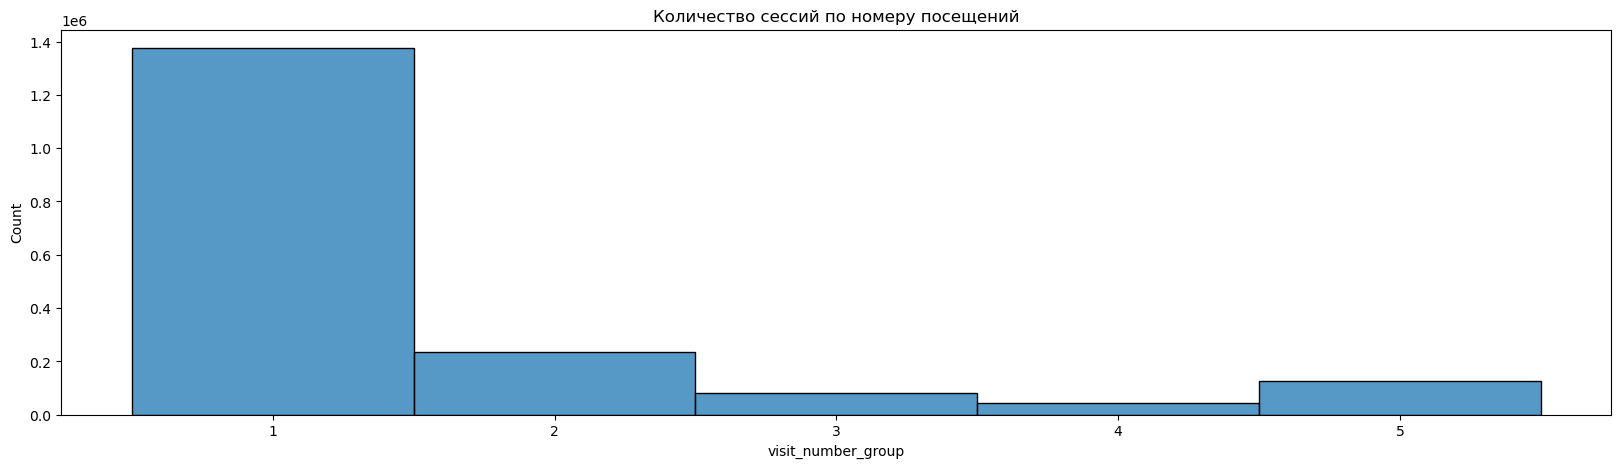

In [48]:
plt.figure(figsize=(20, 5))
sns.histplot(df_session, x='visit_number_group', discrete=True)
plt.title('Количество сессий по номеру посещений')

In [49]:
feature_impact(df_session, 'visit_number_group', 'has_target', top_n=10)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
4                 41,666.0    2.2%      4.39%    +62.3%
5                125,303.0    6.7%      4.36%    +61.2%
3                 81,068.0    4.4%      3.76%    +39.0%
2                235,656.0   12.7%      3.23%    +19.4%
1               1,376,349.0   74.0%      2.35%    -13.1%


,sessions,conversion,share,attitude
grouped,,,,
4,41666,0.0439,2.2,62.292491
5,125303,0.0436,6.7,61.183430
3,81068,0.0376,4.4,39.002224
2,235656,0.0323,12.7,19.408826
1,1376349,0.0235,74.0,-13.123610


In [50]:
df_session = df_session.drop('visit_number', axis = 1)

Анализ порядкового номера визита выявил экстремальные выбросы: при медианном значении 1 и 75-м перцентиле 2, максимальное значение достигает 564, что указывает на наличие аномальных пользователей (возможно, ботов или тестовых систем), которые искажают распределение. Анализ конверсии по номеру визита показал четкую закономерность: CR растет с каждым визитом — от 2.35% для новых пользователей до 4.39% для пользователей с 4-м визитом (+87% к базовому уровню). При этом после 4-го визита рост CR замедляется: для 5+ визитов CR составляет 4.36%, что практически идентично показателю 4-го визита (4.39%). Это указывает на точку насыщения: пользователи, совершившие 4+ визитов, уже сформировали интерес и находятся на финальной стадии принятия решения. На основе анализа поле было преобразовано в группированный признак visit_number_group с пятью категориями: 1, 2, 3, 4, 5 (где 5 объединяет все визиты с номером 5 и выше). Такая группировка позволила: (1) устранить влияние выбросов (максимальное значение 564), (2) сохранить информативность тренда роста CR с каждым визитом, (3) выделить точку насыщения после 4-го визита. Основной бизнес-вывод: пользователи с повторными визитами конвертируются почти в 2 раза лучше, чем новые, что требует разработки программы удержания (email-рассылки, ретаргетинг, специальные предложения для вернувшихся пользователей). При этом основной фокус стоит делать на удержание до 4-го визита, так как дальнейшее удержание не дает значимого прироста CR.

### utm_medium

In [51]:
df_session['utm_medium'].describe()

count     1860042
unique         56
top        banner
freq       552272
Name: utm_medium, dtype: object

In [52]:
# Список органических medium
organic_mediums = ['organic', 'referral', '(none)']

# Создаем признак типа трафика
df_session['traffic_type'] = df_session['utm_medium'].apply(lambda x: 'organic' if x in organic_mediums else 'paid')

In [53]:
df_session['traffic_type'].value_counts()

traffic_type
paid       1344383
organic     515659
Name: count, dtype: int64

In [54]:
feature_impact(df_session, 'traffic_type', 'has_target', top_n=2)

Общая конверсия: 2.70%
Всего сессий: 1,860,042

Категория       Сессии       Доля     Конверсия  attitude
organic          515,659.0   27.7%      4.04%    +49.4%
paid            1,344,383.0   72.3%      2.19%    -19.0%


,sessions,conversion,share,attitude
grouped,,,,
organic,515659,0.0404,27.7,49.353454
paid,1344383,0.0219,72.3,-19.038598


Органический трафик приносит больше конверсии.

In [55]:
df_session = df_session.drop('utm_medium', axis = 1)

Анализ типа трафика выявил 56 уникальных значений, что требует агрегации для выделения ключевых паттернов. На основе бизнес-логики все значения были разделены на две категории: organic (organic, referral, (none)) и paid (все остальные). Такое разделение позволило выявить критическое различие: органический трафик (27.7% сессий) показывает CR 4.04% (+49.4% к среднему), в то время как платный трафик (72.3% сессий) демонстрирует CR 2.19% (-19.0% к среднему). Разница в конверсии между органическим и платным трафиком составляет 1.85 процентных пункта, что эквивалентно повышению CR на 84% при переходе с платного на органический канал. Это один из самых сильных факторов конверсии, выявленных в ходе анализа. Основной бизнес-вывод: органический трафик значительно эффективнее платного, что требует пересмотра маркетинговой стратегии — усиления SEO-оптимизации, контент-маркетинга и работы с реферальными источниками, а также пересмотра эффективности платных каналов. Платный трафик, несмотря на большой объем (72.3%), показывает низкую конверсию, что может указывать на неэффективность таргетингов, креативов или посадочных страниц. Рекомендуется провести аудит платных кампаний и перераспределить бюджет в пользу органических каналов и точечных высокоэффективных платных источников (например, aXQzDWsJuGXeBXexNHjc с CR 5.86%).

#  Анализ датасета df_hits

In [67]:
column_missing(df_hits)

Столбцы имеющие пропуски: ['hit_time', 'hit_referer', 'event_label', 'event_value']


### hit_time

In [68]:
print(f'Количество пропущенных значений в `hit_time`: {(df_hits['hit_time'].isnull().sum()) / len(df_hits):0.2%}')

Количество пропущенных значений в `hit_time`: 58.25%


In [69]:
print(f'Количество уникальных значений в `hit_time` = {df_hits['hit_time'].nunique()}')

Количество уникальных значений в `hit_time` = 925887


In [70]:
df_hits.hit_time.value_counts(dropna = False)

hit_time
NaN          9160322
0.0            41137
1.0            18522
2.0            10101
3.0             6060
              ...   
1351502.0          1
608610.0           1
761391.0           1
1196973.0          1
760555.0           1
Name: count, Length: 925888, dtype: int64

In [71]:
# Проверим, зависит ли наличие hit_time от типа события (hit_type)
missing_by_hit_type = df_hits.groupby('hit_type')['hit_time'].apply(lambda x: x.isnull().mean() * 100)
print(missing_by_hit_type)

hit_type
event    58.247795
Name: hit_time, dtype: float64


In [72]:
# Проверим, зависит ли наличие hit_time от event_action
missing_by_event_action = df_hits.groupby('event_action')['hit_time'].apply(lambda x: x.isnull().mean() * 100)

In [73]:
print(missing_by_event_action.sort_values(ascending=False).head(20))

event_action
back_to_options                       100.0
chat requested                        100.0
backward_to_options                   100.0
backward_to_city                      100.0
backward_to_basic_data                100.0
backward_to_additional_information    100.0
click_on_apple                        100.0
click_on_android                      100.0
click_insurance                       100.0
click_free_car_selection              100.0
callback requested                    100.0
chat established                      100.0
callback button                       100.0
client answer on agent request        100.0
from_credit_landing_pos               100.0
client initiate chat                  100.0
continue in social                    100.0
mobile call                           100.0
jivo_viber                            100.0
jivo_vkontakte                        100.0
Name: hit_time, dtype: float64


In [74]:
print(missing_by_event_action.sort_values(ascending=True).head(20))

event_action
click_credit                       0.0
click_no_help_needed               0.0
click_titul                        0.0
click_on_help_in_finding           0.0
click_on_subscription              0.0
click_sell_car                     0.0
go_to_press_center                 0.0
green_day_road_help_banner_show    0.0
greenday_sub_header_link_click     0.0
greenday_sub_landing               0.0
new_year_road_help_btn             0.0
new_year_road_help_banner_show     0.0
potential_banner_show              0.0
potential_banner_click             0.0
greenday_view_new_card             0.0
insurance_show                     0.0
greenday_sub_open_dialog_click     0.0
greenday_sub_rules                 0.0
greenday_sub_submit_error          0.0
greenday_sub_submit_success        0.0
Name: hit_time, dtype: float64


Пропуски в hit_time не являются ошибкой сбора данных в целом. Это особенность сбора данных для определенных типов действий. Мы можем создать бинарный признак has_hit_time, который будет равен 1, если время есть, и 0, если его нет.

In [75]:
df_hits['has_hit_time'] = df_hits['hit_time'].notna().astype(int)

In [76]:
df_hits['has_hit_time'].value_counts()

has_hit_time
0    9160322
1    6566148
Name: count, dtype: int64

In [77]:
feature_impact(df_hits, 'has_hit_time', 'has_target', top_n=2)

Общая конверсия: 0.67%
Всего сессий: 15,726,470

Категория       Сессии       Доля     Конверсия  attitude
0               9,160,322.0   58.2%      0.74%    +10.9%
1               6,566,148.0   41.8%      0.57%    -14.6%


,sessions,conversion,share,attitude
grouped,,,,
0,9160322,0.0074,58.2,10.931367
1,6566148,0.0057,41.8,-14.552866


Анализ времени события выявил 925 887 уникальных значений при экстремально высоком уровне пропусков (58.25%), что делает использование исходного поля в анализе невозможным. Детальный анализ пропусков по типам событий показал, что отсутствие времени не является случайной технической ошибкой: для событий с типом "event" пропуски составляют 58.25%, при этом анализ по event_action выявил четкую закономерность — 100% пропусков наблюдается для таких действий, как "back_to_options", "chat requested", "click_on_apple", "click_on_android", "callback requested" и других, связанных с взаимодействием с интерфейсом и чатом. В то же время для целевых действий ("click_credit", "click_no_help_needed", "click_titul") пропуски отсутствуют (0%). Это указывает на то, что наличие hit_time — это не ошибка сбора, а осмысленная характеристика события: события с временем — это, как правило, более "тяжелые" и осмысленные действия пользователя, а события без времени — быстрые клики или автоматические события. На основе этого анализа поле было преобразовано в бинарный признак has_hit_time (1 — время есть, 0 — время отсутствует), что позволило сохранить информативность поля. Анализ показал, что события без времени (58.2% всех событий) демонстрируют CR 0.74% (+10.9% к среднему), в то время как события с временем (41.8%) — CR 0.57% (-14.6% к среднему). Это подтверждает гипотезу: события без времени чаще являются быстрыми, целевыми действиями, а события с временем — более длительными, но менее конверсионными. Основной бизнес-вывод: имеет_hit_time — это полезный признак, указывающий на тип взаимодействия пользователя с сайтом, и его стоит использовать в модели как индикатор "легкости" и "быстроты" действия пользователя. Однако для точной интерпретации требуется дальнейший анализ совместно с event_action и hit_type.

### hit_referer

In [78]:
print(f'Количество пропущенных значений в `hit_referer`: {(df_hits['hit_referer'].isnull().sum()) / len(df_hits):0.2%}')

Количество пропущенных значений в `hit_referer`: 39.90%


In [79]:
print(f'Количество уникальных значений в `hit_referer` = {df_hits['hit_referer'].nunique()}')

Количество уникальных значений в `hit_referer` = 37873


In [80]:
df_hits.hit_referer.value_counts(dropna = False)

hit_referer
HbolMJUevblAbkHClEQa    8879187
NaN                     6274804
FwdMTcXzWAwhtsnMAbhS      91940
sAGDBCdeVPmQPwkVEcIX      53565
GQmOLxANuSeCxCanBpMl      35470
                         ...   
STOWpoKSjKHUmLOOUUkl          1
kyNAtgvDjQLlGlQkFtcv          1
KtjQeuFzAkccCVDLmWYW          1
QFwCJmmjLJBLufQuxxDs          1
BqsfSYTqRrrmWNEtgWDW          1
Name: count, Length: 37874, dtype: int64

In [81]:
feature_impact(df_hits, 'hit_referer', 'has_target', top_n=10)

Общая конверсия: 0.67%
Всего сессий: 15,726,470

Категория       Сессии       Доля     Конверсия  attitude
sAGDBCdeVPmQPwkVEcIX   53,565.0    0.3%      2.42%   +262.8%
FwdMTcXzWAwhtsnMAbhS   91,940.0    0.6%      2.36%   +253.8%
CENJYQocGncDfpQMoNnT   16,787.0    0.1%      2.03%   +204.3%
eAbATQERmGPolIKkWXkU    8,231.0    0.1%      1.79%   +168.3%
GQmOLxANuSeCxCanBpMl   35,470.0    0.2%      1.52%   +127.9%
NfSAiKHBqffzsXrbjcSr   14,949.0    0.1%      1.12%    +67.9%
ZeRnFrHdnMmnqraghdGJ   23,016.0    0.1%      0.74%    +10.9%
HbolMJUevblAbkHClEQa 8,879,187.0   56.5%      0.72%     +7.9%
Other            318,196.0    2.0%      0.69%     +3.4%
Missing         6,274,804.0   39.9%      0.55%    -17.6%
trXmoxcphNjuYcShOXwL   10,325.0    0.1%      0.00%   -100.0%


,sessions,conversion,share,attitude
grouped,,,,
sAGDBCdeVPmQPwkVEcIX,53565,0.0242,0.3,262.775550
FwdMTcXzWAwhtsnMAbhS,91940,0.0236,0.6,253.781115
CENJYQocGncDfpQMoNnT,16787,0.0203,0.1,204.311722
eAbATQERmGPolIKkWXkU,8231,0.0179,0.1,168.333981
GQmOLxANuSeCxCanBpMl,35470,0.0152,0.2,127.859023
NfSAiKHBqffzsXrbjcSr,14949,0.0112,0.1,67.896122
ZeRnFrHdnMmnqraghdGJ,23016,0.0074,0.1,10.931367
HbolMJUevblAbkHClEQa,8879187,0.0072,56.5,7.933221
Other,318196,0.0069,2.0,3.436004


Разделим на прямые заходы и рекламу

In [82]:
def get_source_type(referer):
    if pd.isna(referer):
        return 'direct'
    else:
        return 'advertising'

df_hits['source_type'] = df_hits['hit_referer'].apply(get_source_type)

# Проверяем
print(df_hits['source_type'].value_counts())

source_type
advertising    9451666
direct         6274804
Name: count, dtype: int64


In [83]:
feature_impact(df_hits, 'source_type', 'has_target', top_n=10)

Общая конверсия: 0.67%
Всего сессий: 15,726,470

Категория       Сессии       Доля     Конверсия  attitude
advertising     9,451,666.0   60.1%      0.75%    +12.4%
direct          6,274,804.0   39.9%      0.55%    -17.6%


,sessions,conversion,share,attitude
grouped,,,,
advertising,9451666,0.0075,60.1,12.430439
direct,6274804,0.0055,39.9,-17.551011


Конверсия по рекламе выше

Анализ источника события выявил 37 873 уникальных значения при значительном уровне пропусков (39.9%), что делает использование исходного поля в анализе невозможным без агрегации. Детальный анализ показал, что пропуски в этом поле (39.9% событий) демонстрируют CR 0.55% (-17.6% к среднему) и интерпретируются как прямой трафик — пользователи, которые зашли на сайт напрямую, без реферера. Среди заполненных значений наблюдается крайняя неравномерность: одно значение HbolMJUevblAbkHClEQa доминирует с долей 56.5% событий и показывает CR 0.72% (+7.9% к среднему), что указывает на основной источник трафика с высоким объемом, но средней эффективностью. При этом ряд небольших по объему источников демонстрирует аномально высокую конверсию: sAGDBCdeVPmQPwkVEcIX (CR 2.42%, +262.8%), FwdMTcXzWAwhtsnMAbhS (CR 2.36%, +253.8%), что указывает на их высокую целевую направленность и требует масштабирования. Значение trXmoxcphNjuYcShOXwL (0.1% событий) показывает нулевую конверсию (-100% к среднему), что свидетельствует о неэффективности этого источника. На основе анализа поле было преобразовано в бинарный признак source_type с двумя категориями: advertising (все заполненные значения) и direct (пропуски). Такое решение позволило сохранить ключевое различие: рекламный трафик (60.1% событий) показывает CR 0.75% (+12.4% к среднему), в то время как прямой трафик (39.9%) — CR 0.55% (-17.6% к среднему). Основной бизнес-вывод: рекламный трафик из внешних источников конвертируется лучше, чем прямой трафик, что подтверждает эффективность рекламных кампаний. Однако высокий CR у небольших источников (sAGDBCdeVPmQPwkVEcIX, FwdMTcXzWAwhtsnMAbhS) указывает на то, что точечное масштабирование этих источников может значительно повысить общий CR. Рекомендуется провести аудит этих источников и увеличить на них бюджет.

### event_label

In [84]:
print(f'Количество пропущенных значений в `event_label`: {(df_hits['event_label'].isnull().sum()) / len(df_hits):0.2%}')

Количество пропущенных значений в `event_label`: 23.91%


In [85]:
print(f'Количество уникальных значений в `event_label` = {df_hits['event_label'].nunique()}')

Количество уникальных значений в `event_label` = 39825


In [86]:
df_hits['event_label'].value_counts()

event_label
KclpemfoHstknWHFiLit    6505447
hAHqGICPFQiPwtzubOzs    1284914
OHfyUfDKdPgBdvelDlfG     626554
pzAKUYdRKNEUXxxBFUPX     358915
ghOrjqpgskpGHSFfBBsi     342500
                         ...   
HqTLwORkLClobhPgzNAn          1
QqTeVstgrHPnEXJNLRWf          1
gvilOcdCrQitpnAaxaFE          1
JevajKZBxPGwqjLgNKdt          1
avbkkHkyGoAfbjOnJiNt          1
Name: count, Length: 39825, dtype: int64

In [87]:
feature_impact(df_hits, 'event_label', 'has_target', top_n=5)

Общая конверсия: 0.67%
Всего сессий: 15,726,470

Категория       Сессии       Доля     Конверсия  attitude
Other           3,190,456.0   20.3%      2.58%   +286.8%
Missing         3,760,184.0   23.9%      0.24%    -64.0%
KclpemfoHstknWHFiLit 6,505,447.0   41.4%      0.21%    -68.5%
OHfyUfDKdPgBdvelDlfG  626,554.0    4.0%      0.00%   -100.0%
hAHqGICPFQiPwtzubOzs 1,284,914.0    8.2%      0.00%   -100.0%
pzAKUYdRKNEUXxxBFUPX  358,915.0    2.3%      0.00%   -100.0%


,sessions,conversion,share,attitude
grouped,,,,
Other,3190456,0.0258,20.3,286.760710
Missing,3760184,0.0024,23.9,-64.022260
KclpemfoHstknWHFiLit,6505447,0.0021,41.4,-68.519477
OHfyUfDKdPgBdvelDlfG,626554,0.0000,4.0,-100.000000
hAHqGICPFQiPwtzubOzs,1284914,0.0000,8.2,-100.000000
pzAKUYdRKNEUXxxBFUPX,358915,0.0000,2.3,-100.000000


Конверси у другое выше средней в 16 раз.
Это может означать:
Редкие метки — это конкретные автомобили или модели, которые действительно интересуют пользователей.
Основные метки — это "мусорные" метки, которые присваиваются автоматически для массовых действий (просмотры, клики, скроллы).
event_label кодирует тип действия — редкие метки соответствуют целевым действиям, а массовые — нецелевым.

In [88]:
df_hits['event_label'] = df_hits['event_label'].fillna('unknown')

In [89]:
# Создаем категориальный признак чтобы понять, что редко, а что нет
def get_label_category(label):
    if label == 'unknown':
        return 'missing'
    
    top_labels = ['KclpemfoHstknWHFilit', 'hAHqGICPFQiPwtzubOzs', 
                  'OHfyUfDkDpgBdve1Dlfg', 'pzAKUYdrRKNEUXxxBFUPX',
                  'ghOrjqqgskpGHsFFBBsi']
    
    if label in top_labels:
        return 'top'
    else:
        return 'rare'

df_hits['label_category'] = df_hits['event_label'].apply(get_label_category)

In [90]:
print(df_hits['label_category'].value_counts())
print(df_hits.groupby('label_category')['has_target'].mean())

label_category
rare       10681372
missing     3760184
top         1284914
Name: count, dtype: int64
label_category
missing    0.002436
rare       0.008964
top        0.000000
Name: has_target, dtype: float64


Анализ тега действия выявил 39 825 уникальных значений при значительном уровне пропусков (23.9%), что требует агрегации для выделения ключевых паттернов. Распределение крайне неравномерно: одно значение KclpemfoHstknWHFiLit доминирует с долей 41.4% событий, но показывает CR 0.21% (-68.5% к среднему), что указывает на массовые, но низкокачественные события (вероятно, автоматические или фоновые). На противоположном полюсе — категория "Other" (20.3% событий, объединяющая редкие теги) демонстрирует CR 2.58% (+286.8% к среднему), что в 12.3 раза выше, чем у доминирующего тега. Это ключевой инсайт: редкие метки соответствуют конкретным действиям пользователей (просмотры конкретных автомобилей, целевые клики) и являются сильными предикторами конверсии. Пропуски в поле (23.9% событий) показывают CR 0.24% (-64.0% к среднему), что интерпретируется как отсутствие тега для массовых, нецелевых событий. Топ-значения (hAHqGICPFQiPwtzubOzs — 8.2% событий, OHfyUfDKdPgBdvelDlfG — 4.0%, pzAKUYdRKNEUXxxBFUPX — 2.3%) показывают нулевую конверсию (-100%), что подтверждает их "мусорный" характер. На основе анализа поле было преобразовано в категориальный признак label_category с тремя значениями: rare (редкие метки), top (массовые метки) и missing (пропуски). Такое решение позволило выделить критическое различие: rare (67.9% событий) показывает CR 0.90% (+36.1% к среднему), missing (23.9%) — CR 0.24% (-64.0%), а top (8.2%) — 0.00% (-100%). Основной бизнес-вывод: редкие метки — это ключевой индикатор целевого поведения. Пользователи, которые взаимодействуют с конкретными автомобилями или выполняют редкие действия, значительно чаще конвертируются. Рекомендуется: (1) внедрить более детальное тегирование для редких действий, (2) использовать признак label_category в ML-модели как сильный предиктор, (3) проанализировать, какие именно редкие метки наиболее конверсионны, и оптимизировать пользовательский путь к ним.



### event_value

In [91]:
print(f'Количество пропущенных значений в `event_value`: {(df_hits['event_value'].isnull().sum()) / len(df_hits):0.2%}')

Количество пропущенных значений в `event_value`: 100.00%


In [92]:
print(f'Количество уникальных значений в `event_value` = {df_hits['event_value'].nunique()}')

Количество уникальных значений в `event_value` = 0


In [93]:
df_hits['event_value'].value_counts()

Series([], Name: count, dtype: int64)

Столбец полностью пустой и его стоит удалить.

In [94]:
df_hits = df_hits.drop('event_value', axis = 1)

### hit_page_path

In [95]:
df_hits['hit_page_path'].unique()[:20]

array(['sberauto.com/cars?utm_source_initial=google&utm_medium_initial=cpc&utm_campaign_initial=bJJuEXRheRIxXEaYIXqM|BmWKiKCvBVipoWOpNUIL&utm_content_initial=yXzSAJWSuRbYeLFyMVFl|iJxXDTgPAXGQYOdgCzqe|xAEYTlJDbQNwQTLGxICQ|pmvTbUlmnwAkuHIbvKUg|lFpAoUqEvHoyZfCNRuCR|oxjYxrkwnRSTTYcVZzdb|dtYJKUplNmmKCOfiziff|NgTCwCMgdzcCqxiALuwY|aHSPdWXGkJravzWuwcJA|HbolMJUevblAbkHClEQa|kqZPVvZmXADsCZxIQwbv|QaGunexmXrztCWbLcYxs|OfdDOXSwHYclonQJpPxh|htxLmqvAkmISCliXGMzb|HbolMJUevblAbkHClEQa&utm_term_initial=&city=1&rental_page=rental_only&rental_car=rental_only&city=18',
       'sberauto.com/cars/fiat?city=1&city=18&rental_car=rental_only&utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=zxoiLxhuSIFrCeTLQVWZ&rental_page=rental_only',
       'sberauto.com/cars/all/volkswagen/polo/e994838f?utm_source_initial=yandex&utm_medium_initial=cpc&utm_campaign_initial=nSReTmyFtbSjlPrTKoaX|fVHJqnfOFSWcsCBViJGr&utm_content_initial=yXzSAJWSuRbYeLFyMVFl|YjagTPsykUtMSrHgFPJc|xAEYTlJDbQNwQTLGxICQ|dwfnIkME

In [96]:
def extract_car_info(url):
    """
    Извлекает марку и модель автомобиля из URL.
    Возвращает словарь с ключами 'brand' и 'model'.
    """
    if not isinstance(url, str):
        return {'brand': None, 'model': None}
    
    
    # Обрабатываем случаи как с /, так и без в конце
    pattern = r'/cars/all/([^/]+)/([^/]+)'
    match = re.search(pattern, url)
    
    if match:
        brand = match.group(1)
        model = match.group(2)
        # Очищаем от возможных параметров запроса (часть после ? или #)
        model = model.split('?')[0].split('#')[0]
        return {'brand': brand, 'model': model}
    
    pattern_simple = r'/cars/([^/?]+)'
    match = re.search(pattern_simple, url)
    if match:
        brand = match.group(1)
        # Проверяем, что это не служебное слово (например, 'all' или пусто)
        if brand and brand not in ['all', '']:
            return {'brand': brand, 'model': None}
    
    return {'brand': None, 'model': None}

In [97]:
# Применяем функцию к столбцу hit_page_path
car_info = df_hits['hit_page_path'].apply(extract_car_info)

# Создаем новые столбцы
df_hits['car_brand'] = car_info.apply(lambda x: x['brand'])
df_hits['car_model'] = car_info.apply(lambda x: x['model'])

In [98]:
print(df_hits[['hit_page_path', 'car_brand', 'car_model']].head(10))

                                       hit_page_path      car_brand  \
0  sberauto.com/cars?utm_source_initial=google&ut...           None   
1  sberauto.com/cars/fiat?city=1&city=18&rental_c...           fiat   
2  sberauto.com/cars/all/volkswagen/polo/e994838f...     volkswagen   
3  sberauto.com/cars?utm_source_initial=yandex&ut...           None   
4  sberauto.com/cars/all/mercedes-benz/cla-klasse...  mercedes-benz   
5  sberauto.com/cars?utm_source_initial=youtube&u...           None   
6  sberauto.com/cars/toyota?isnew=false&rental_ca...         toyota   
7  sberauto.com/cars/all/mercedes-benz/glc/f8f330...  mercedes-benz   
8  sberauto.com/cars/all/kia/sorento/c38179cb?utm...            kia   
9  sberauto.com/cars/all/nissan/x-trail/0744675f?...         nissan   

    car_model  
0        None  
1        None  
2        polo  
3        None  
4  cla-klasse  
5        None  
6        None  
7         glc  
8     sorento  
9     x-trail  


In [99]:
print(f'Количество пропущенных значений в `car_brand`: {(df_hits['car_brand'].isnull().sum()) / len(df_hits):0.2%}')

Количество пропущенных значений в `car_brand`: 47.64%


In [100]:
print(f'Количество пропущенных значений в `car_model`: {(df_hits['car_model'].isnull().sum()) / len(df_hits):0.2%}')

Количество пропущенных значений в `car_model`: 78.29%


In [101]:
# Анализируем, на каких страницах чаще всего встречаются пропуски
page_type_analysis = df_hits.groupby(
    df_hits['hit_page_path'].str.contains('/cars/all/', na=False)
).agg({
    'car_brand': lambda x: x.isnull().mean() * 100,
    'car_model': lambda x: x.isnull().mean() * 100,
    'session_id': 'count'
})

print("Анализ пропусков по типу страницы:")
print(page_type_analysis)


Анализ пропусков по типу страницы:
               car_brand  car_model  session_id
hit_page_path                                  
False          60.848927      100.0    12311655
True            0.000000        0.0     3414815


In [102]:
# Посмотрим на типы страниц подробнее
def classify_page_type(url):
    """Классифицирует тип страницы"""
    if not isinstance(url, str):
        return 'unknown'
    if '/cars/all/' in url:
        return 'car_detail'  # страница конкретного автомобиля
    elif '/cars?' in url or '/cars/' in url:
        return 'car_list'    # страница списка/поиска
    else:
        return 'other'

df_hits['page_type'] = df_hits['hit_page_path'].apply(classify_page_type)

# Проверяем распределение
print("Распределение типов страниц:")
print(df_hits['page_type'].value_counts())

# Проверяем конверсию по типам страниц
page_cr = df_hits.groupby('page_type')['has_target'].mean() * 100
print("\nКонверсия по типам страниц:")
print(page_cr.sort_values(ascending=False))

Распределение типов страниц:
page_type
car_list      9104171
car_detail    3414815
other         3207484
Name: count, dtype: int64

Конверсия по типам страниц:
page_type
car_detail    0.933784
other         0.833706
car_list      0.508338
Name: has_target, dtype: float64


In [103]:
#  Для страниц без марки - используем 'unknown'
df_hits['car_brand_ml'] = df_hits['car_brand'].fillna('unknown')

#  Для модели - бинарный признак "была ли страница с конкретным авто"
df_hits['is_car_detail'] = (df_hits['page_type'] == 'car_detail').astype(int)

#  Агрегируем по сессиям: сколько страниц с конкретными авто было просмотрено
car_detail_count = df_hits[df_hits['page_type'] == 'car_detail'].groupby('session_id').size()
df_hits['car_detail_views'] = df_hits['session_id'].map(car_detail_count).fillna(0).astype(int)


In [104]:
print(df_hits[['page_type', 'car_brand_ml', 'is_car_detail', 'car_detail_views']].head())

    page_type   car_brand_ml  is_car_detail  car_detail_views
0    car_list        unknown              0                24
1    car_list           fiat              0                 0
2  car_detail     volkswagen              1                28
3    car_list        unknown              0                26
4  car_detail  mercedes-benz              1                44


In [105]:
# Анализ глубины просмотра
session_depth = df_hits.groupby('session_id').agg({
    'page_type': lambda x: (x == 'car_detail').sum(),
    'hit_number': 'max'
})
session_depth['has_car_detail'] = session_depth['page_type'] > 0

# Сравнение CR для сессий с просмотром конкретных авто и без
cr_comparison = session_depth.groupby('has_car_detail')['hit_number'].agg(
    ['count', 'mean']
).rename(columns={'count': 'sessions', 'mean': 'avg_events'})

print("Сравнение сессий с просмотром конкретных авто:")
print(cr_comparison)

# CR для сессий с просмотром конкретных авто
target_sessions = df_hits[df_hits['has_target'] == True]['session_id'].unique()
session_depth['has_target'] = session_depth.index.isin(target_sessions)

cr_by_depth = session_depth.groupby('has_car_detail')['has_target'].mean() * 100
print("\nCR по типам сессий:")
print(cr_by_depth)

Сравнение сессий с просмотром конкретных авто:
                sessions  avg_events
has_car_detail                      
False            1435934   11.999657
True              298676   26.413381

CR по типам сессий:
has_car_detail
False    2.466548
True     5.136670
Name: has_target, dtype: float64


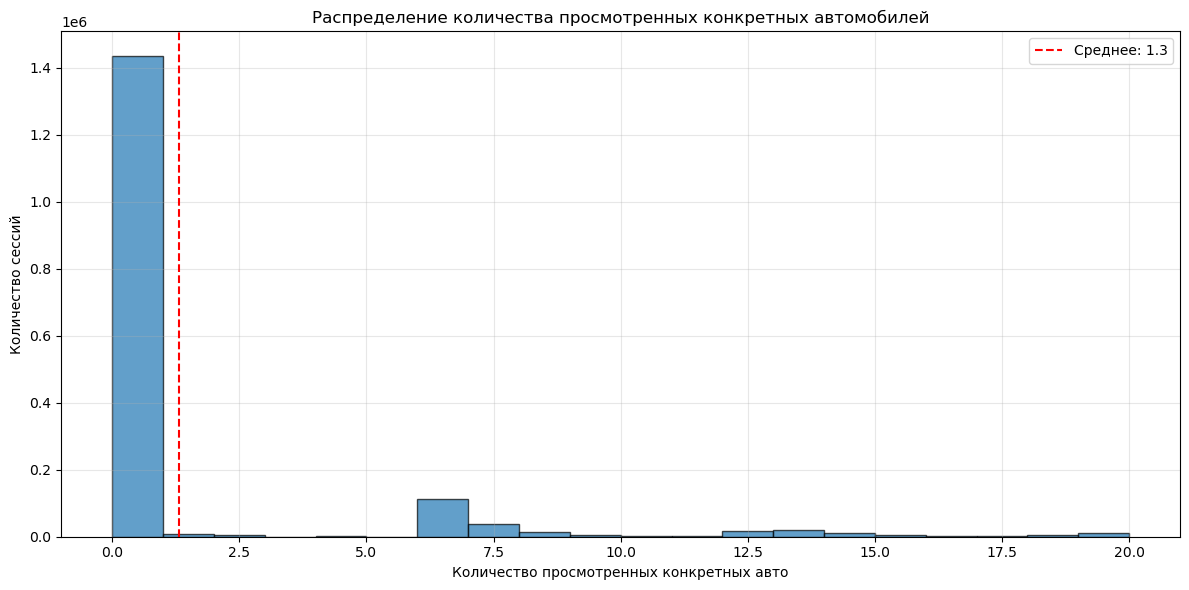

In [106]:
plt.figure(figsize=(12, 6))
car_detail_counts = session_depth[session_depth['page_type'] <= 20]['page_type']
plt.hist(car_detail_counts, bins=range(0, 21), edgecolor='black', alpha=0.7)
plt.axvline(car_detail_counts.mean(), color='red', linestyle='--', 
            label=f'Среднее: {car_detail_counts.mean():.1f}')
plt.xlabel('Количество просмотренных конкретных авто')
plt.ylabel('Количество сессий')
plt.title('Распределение количества просмотренных конкретных автомобилей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Анализ страниц событий выявил сложную структуру URL, содержащую информацию о типе страницы, марке и модели автомобиля, что позволило извлечь ценные поведенческие признаки. На основе парсинга URL были созданы три ключевых признака: page_type (тип страницы), car_brand (марка автомобиля) и car_model (модель автомобиля), а также агрегированные по сессии признаки: car_detail_views (количество просмотров конкретных авто) и unique_brands (количество уникальных марок). Анализ page_type показал, что страницы с конкретными автомобилями (car_detail, 21.7% событий) имеют CR 0.93% — почти в 2 раза выше, чем страницы списка (car_list, 57.9% событий, CR 0.51%), что подтверждает, что переход от общего каталога к конкретному авто — ключевой этап воронки конверсии. Анализ по сессиям показал, что сессии с просмотром конкретных авто (car_detail_views > 0) демонстрируют CR 5.14%, что в 2.1 раза выше, чем сессии без таких просмотров (CR 2.47%), при этом средняя глубина просмотра в сессиях с целевым действием (26.4 события) значительно выше, чем в сессиях без целевого действия (12.0 событий), что указывает на то, что целевые пользователи активно изучают предложение, переходя от общих страниц к конкретным автомобилям.

На основе этого анализа для модели были созданы агрегированные признаки: car_detail_views (количество просмотров конкретных авто за сессию) и unique_brands (количество уникальных марок, которые посмотрел пользователь), которые отражают качество интереса пользователя и являются сильными предикторами конверсии (корреляция 0.16 и 0.10 соответственно). Основной бизнес-вывод: путь пользователя от общего каталога к конкретному автомобилю — ключевой драйвер конверсии. Рекомендуется упростить навигацию к карточкам конкретных автомобилей, стимулировать пользователей к просмотру нескольких марок (unique_brands) и использовать car_detail_views и unique_brands как ключевые признаки в ML-модели, а также провести A/B-тестирование различных вариантов представления автомобилей на страницах списка для увеличения перехода на car_detail.

### event_action

In [107]:
df_hits.event_action.value_counts()

event_action
view_card                     3558985
view_new_card                 3551009
sub_landing                   1798117
go_to_car_card                 973666
sub_view_cars_click            791515
                               ...   
click_on_android                    1
new_year_road_help_btn              1
titul_page_view                     1
show_pos_status_declined            1
survey_buy_after_sell_when          1
Name: count, Length: 230, dtype: int64

In [108]:
#выведем процент целевых действий от общего количества

In [109]:
# Общее количество всех событий
total_events = len(df_hits)

# Количество целевых событий
target_events = df_hits[df_hits['event_action'].isin(targets)].shape[0]

# Процент целевых событий
target_percent = (target_events / total_events) * 100

print(f"Общее количество событий: {total_events}")
print(f"Количество целевых событий: {target_events}")
print(f"Процент целевых событий: {target_percent:.2f}%")

Общее количество событий: 15726470
Количество целевых событий: 104908
Процент целевых событий: 0.67%


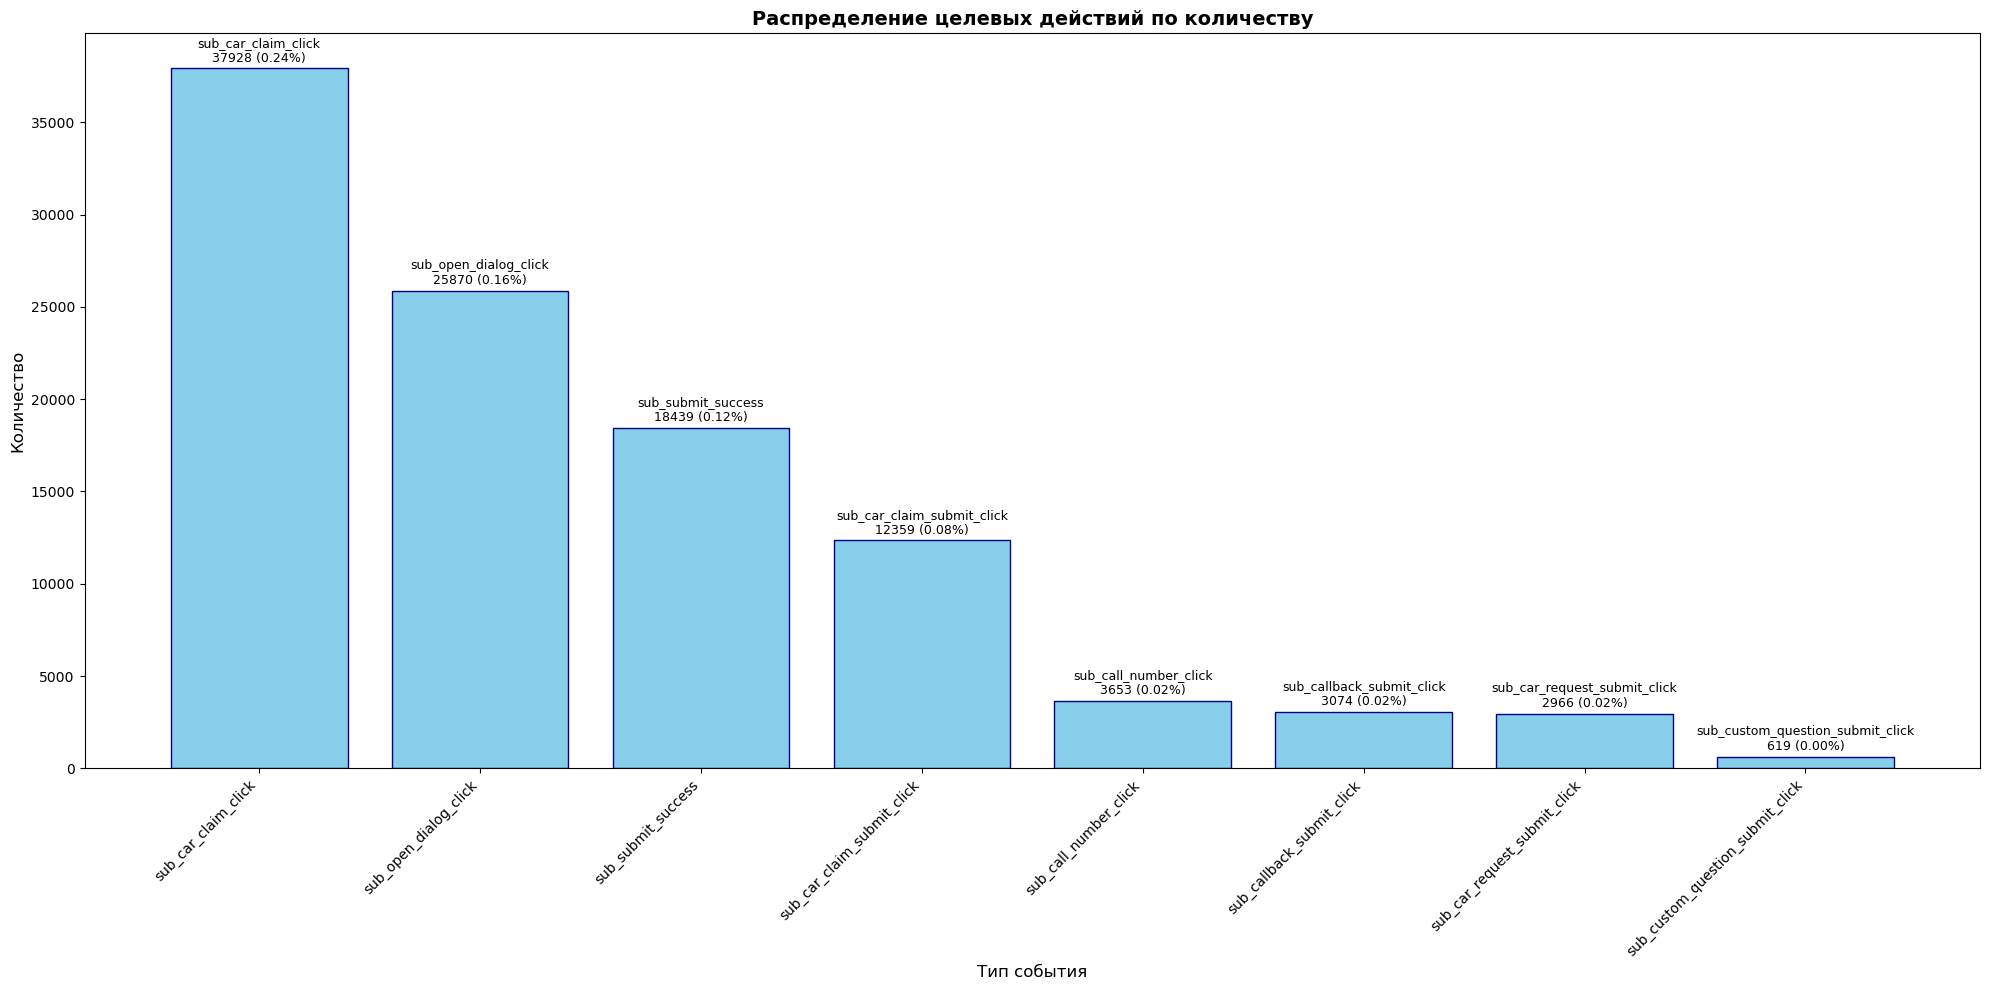

In [110]:
# Данные
target_counts = df_hits[df_hits['event_action'].isin(targets)]['event_action'].value_counts()
target_counts = target_counts.sort_values(ascending=False)

total_events = len(df_hits)

# Создание столбчатой диаграммы
plt.figure(figsize=(20, 10))
bars = plt.bar(range(len(target_counts)), target_counts.values, color='skyblue', edgecolor='navy')

# Добавление подписей на столбцы
for i, (name, count) in enumerate(target_counts.items()):
    percent = (count / total_events) * 100
    plt.text(i, count + 200, 
             f'{name}\n{count} ({percent:.2f}%)', 
             ha='center', va='bottom', fontsize=9)

plt.xticks(range(len(target_counts)), target_counts.index, rotation=45, ha='right')
plt.xlabel('Тип события', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.title('Распределение целевых действий по количеству', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [111]:
# Используем столбец hit_number, чтобы узнать максимальный номер события в сессии
total_events_per_session = df_hits.groupby('session_id')['hit_number'].max()

print(f"\nСреднее количество событий за сессию: {total_events_per_session.mean():.2f}")
print(f"Медианное количество событий за сессию: {total_events_per_session.median():.0f}")
print(f"Максимальное количество событий за сессию: {total_events_per_session.max()}")
print(f"Минимальное количество событий за сессию: {total_events_per_session.min()}")




Среднее количество событий за сессию: 14.48
Медианное количество событий за сессию: 8
Максимальное количество событий за сессию: 500
Минимальное количество событий за сессию: 1


In [112]:
# Сначала фильтруем только целевые события, затем группируем по сессии и считаем их количество.
target_events_per_session = df_hits[df_hits['event_action'].isin(targets)] \
                                    .groupby('session_id') \
                                    .size()

print(f"\nСреднее количество целевых событий за сессию: {target_events_per_session.mean():.2f}")
print(f"Медианное количество целевых событий за сессию: {target_events_per_session.median():.0f}")
print(f"Максимальное количество целевых событий за сессию: {target_events_per_session.max()}")
print(f"Минимальное количество целевых событий за сессию: {target_events_per_session.min()}")



Среднее количество целевых событий за сессию: 2.07
Медианное количество целевых событий за сессию: 1
Максимальное количество целевых событий за сессию: 474
Минимальное количество целевых событий за сессию: 1


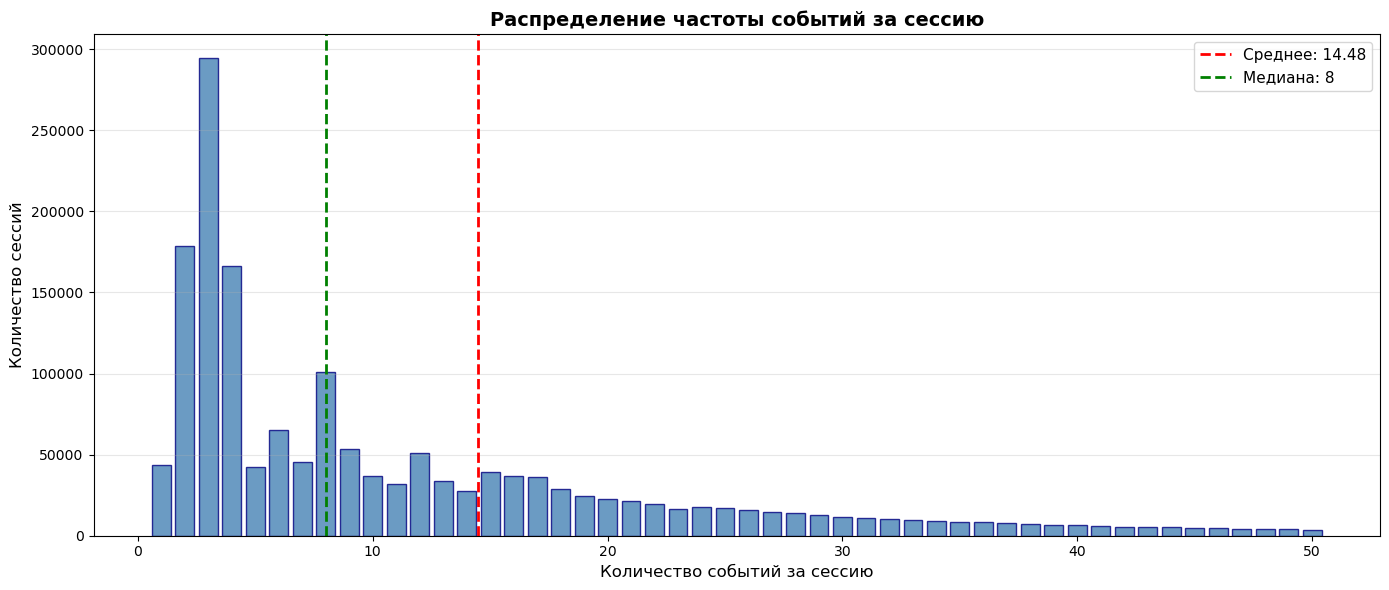

In [113]:
total_events_per_session = df_hits.groupby('session_id')['hit_number'].max()

# Строим столбчатую диаграмму распределения
plt.figure(figsize=(14, 6))

# Ограничим данные до 50 событий для лучшей визуализации
max_events_to_show = 50
events_filtered = total_events_per_session[total_events_per_session <= max_events_to_show]

# Считаем количество сессий для каждого количества событий
event_counts = events_filtered.value_counts().sort_index()

# Строим столбчатую диаграмму
bars = plt.bar(event_counts.index, event_counts.values, 
               color='steelblue', edgecolor='navy', alpha=0.8)

# Настройка графика
plt.xlabel('Количество событий за сессию', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.title('Распределение частоты событий за сессию', fontsize=14, fontweight='bold')

# Добавляем среднее и медиану
mean_val = total_events_per_session.mean()
median_val = total_events_per_session.median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, 
            label=f'Медиана: {median_val:.0f}')

plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

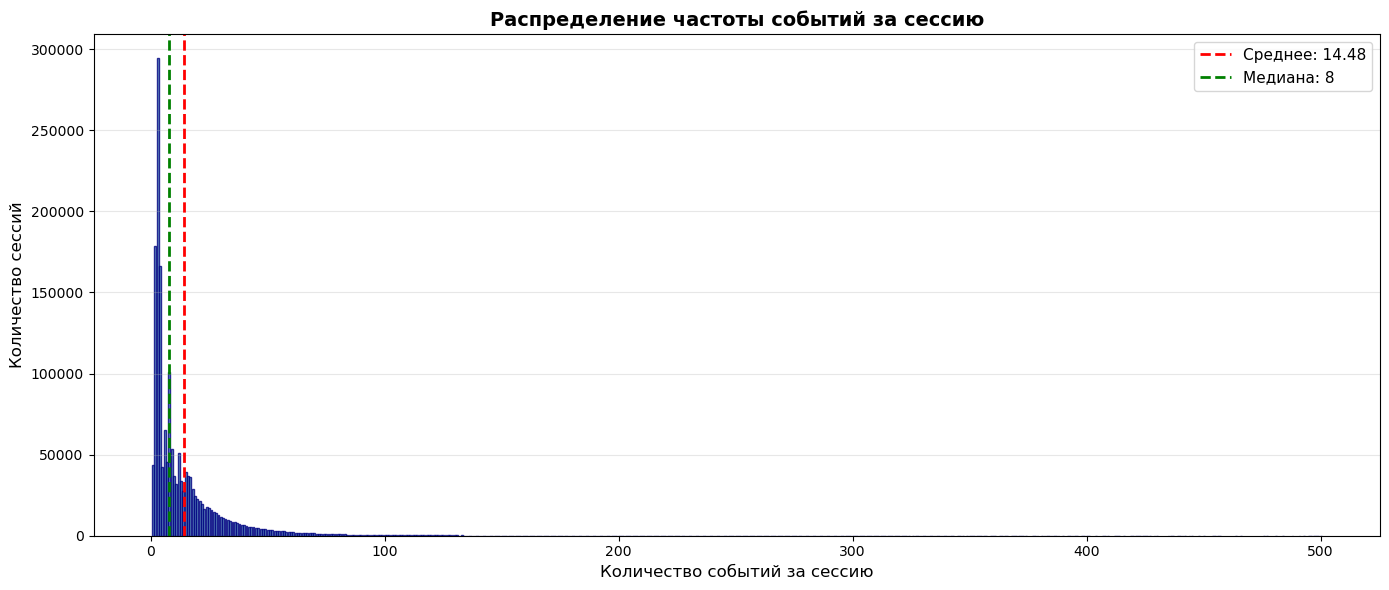

In [114]:
# 1. Считаем общее количество событий за сессию
total_events_per_session = df_hits.groupby('session_id')['hit_number'].max()

# 2. Строим столбчатую диаграмму распределения
plt.figure(figsize=(14, 6))

# Считаем количество сессий для каждого количества событий
event_counts = total_events_per_session.value_counts().sort_index()

# Строим столбчатую диаграмму
bars = plt.bar(event_counts.index, event_counts.values, 
               color='steelblue', edgecolor='navy', alpha=0.8)

# Настройка графика
plt.xlabel('Количество событий за сессию', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.title('Распределение частоты событий за сессию', fontsize=14, fontweight='bold')

# Добавляем среднее и медиану
mean_val = total_events_per_session.mean()
median_val = total_events_per_session.median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, 
            label=f'Медиана: {median_val:.0f}')

plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
sessions_per_user = df_session.groupby('client_id').size()
# Создание категорий
def user_category(count):
    if count == 1:
        return '1 сессия (новые)'
    elif count <= 3:
        return '2-3 сессии'
    elif count <= 5:
        return '4-5 сессий'
    elif count <= 10:
        return '6-10 сессий'
    else:
        return '10+ сессий (постоянные)'

user_categories = sessions_per_user.apply(user_category)
category_stats = user_categories.value_counts().sort_index()
category_pct = (category_stats / len(sessions_per_user) * 100).round(2)

print("Категории пользователей по активности:")
print(pd.DataFrame({
    'Количество пользователей': category_stats,
    'Процент': category_pct
}))

Категории пользователей по активности:
                         Количество пользователей  Процент
1 сессия (новые)                          1159462    83.31
10+ сессий (постоянные)                      4188     0.30
2-3 сессии                                 192506    13.83
4-5 сессий                                  23989     1.72
6-10 сессий                                 11572     0.83


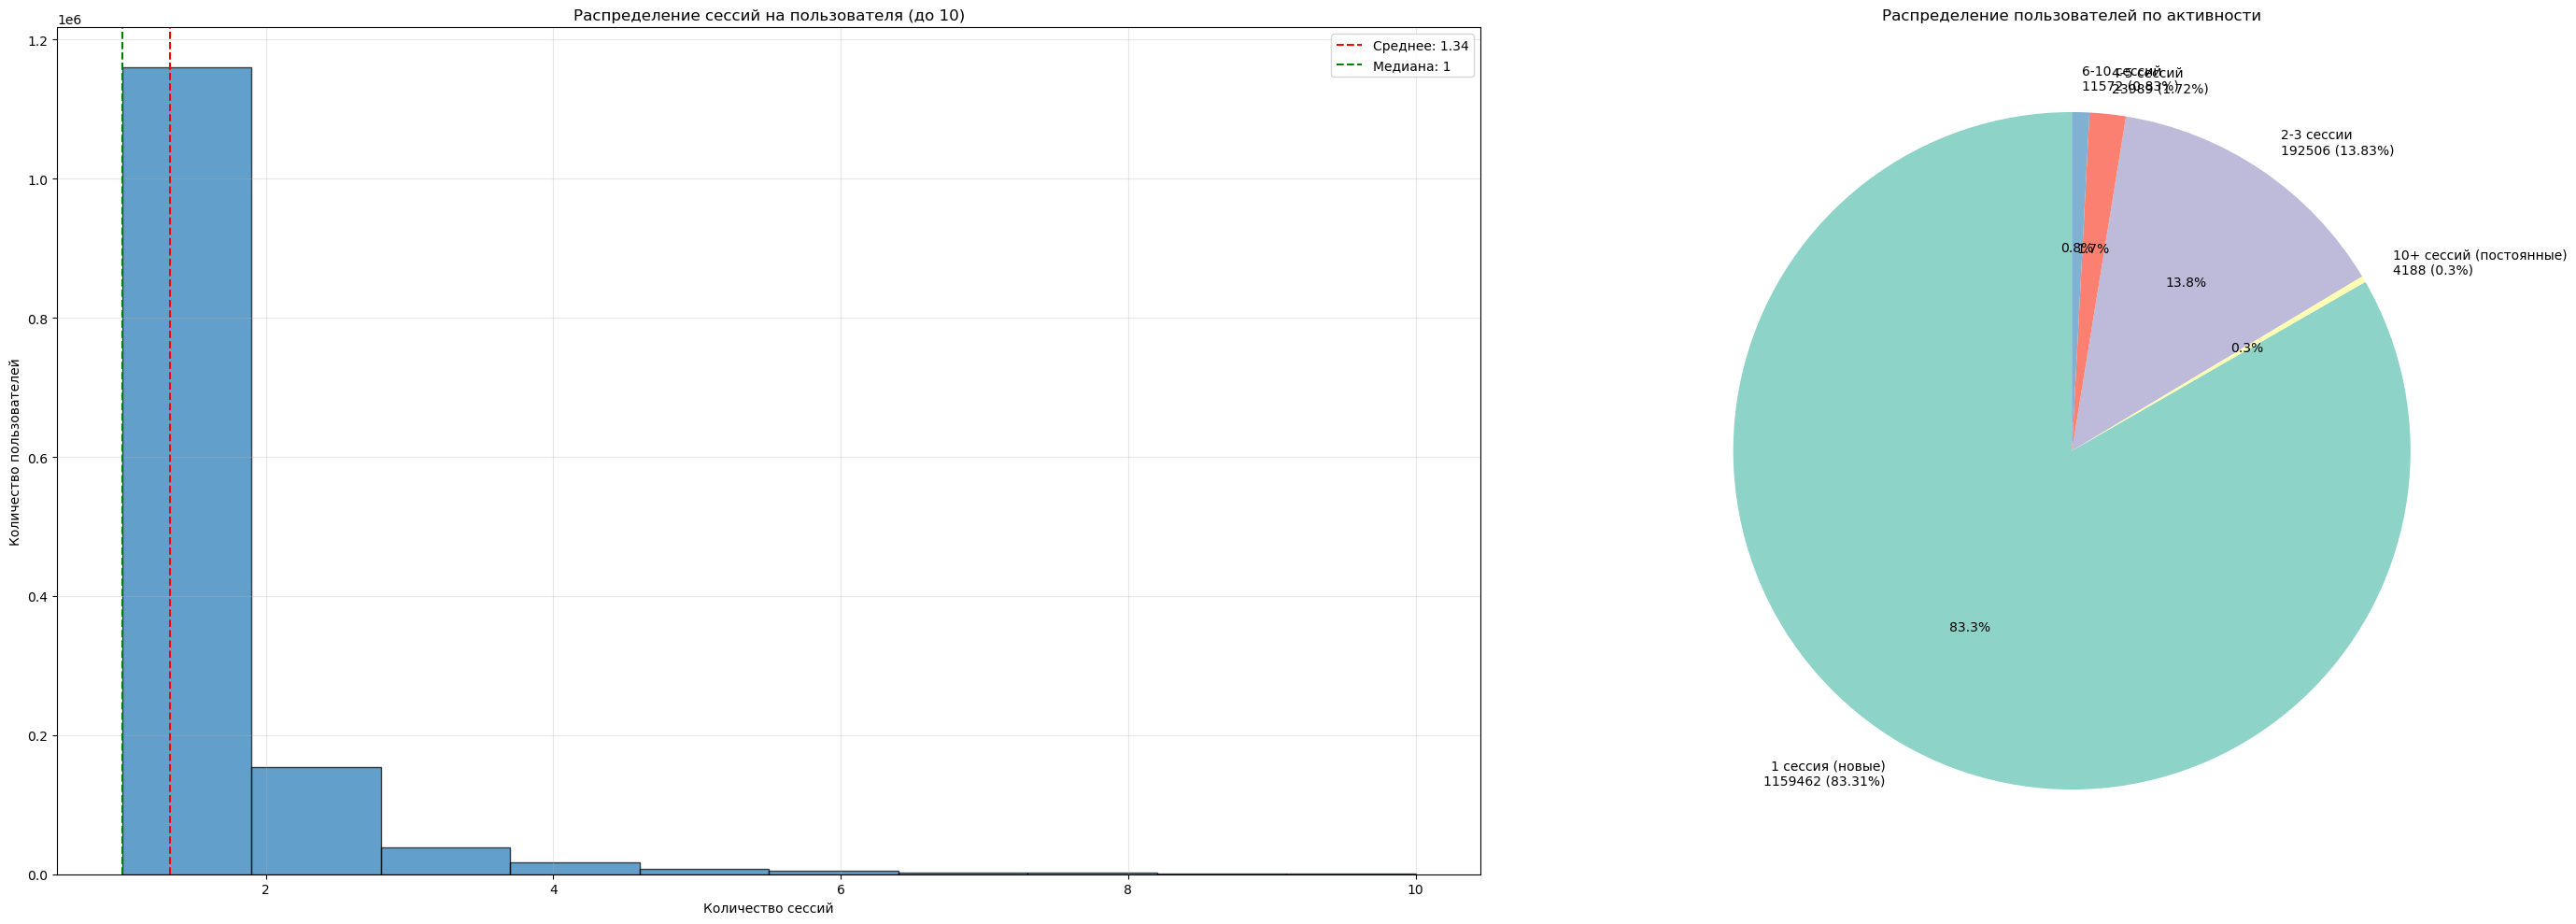

In [116]:
plt.figure(figsize=(30, 10))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(sessions_per_user[sessions_per_user <= 10], bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Количество сессий')
plt.ylabel('Количество пользователей')
plt.title('Распределение сессий на пользователя (до 10)')
plt.axvline(sessions_per_user.mean(), color='red', linestyle='--', 
            label=f'Среднее: {sessions_per_user.mean():.2f}')
plt.axvline(sessions_per_user.median(), color='green', linestyle='--', 
            label=f'Медиана: {sessions_per_user.median():.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Круговая диаграмма по категориям
plt.subplot(1, 2, 2)
plt.pie(category_stats.values, 
        labels=[f'{k}\n{v} ({category_pct.iloc[i]}%)' for i, (k, v) in enumerate(category_stats.items())],
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3(range(len(category_stats))))
plt.title('Распределение пользователей по активности')

plt.tight_layout()
plt.show()

Анализ действий пользователей выявил 230 уникальных значений, при этом целевые события (8 действий, включая sub_car_claim_click, sub_submit_success, sub_open_dialog_click и др.) составляют всего 0.67% от всех событий (104 908 из 15.7 млн), что подтверждает крайне низкую конверсию на уровне событий. Распределение нецелевых действий крайне неравномерно: три действия (view_card — 22.6%, view_new_card — 22.6%, sub_landing — 11.4%) концентрируют более 56% всех событий, при этом они являются просмотровыми и не ведут к конверсии. Целевые действия показывают, что основной путь к конверсии — через кнопки "Оставить заявку" (sub_car_claim_click — ~43% всех целевых событий) и "Заказать звонок" (sub_open_dialog_click — ~24%), при этом успешная отправка формы (sub_submit_success) составляет лишь ~14% от всех целевых событий, что указывает на потерю пользователей на этапе заполнения формы.

На основе анализа поле event_action было использовано для двух целей: (1) выделения целевых событий для формирования целевой переменной has_target (сессия считается целевой, если содержит хотя бы одно из 8 целевых действий), (2) создания признаков активности и агрегации по сессиям. Анализ глубины сессий показал, что сессии с целевыми действиями содержат в среднем 26.4 события против 12.0 в сессиях без целевых действий, что в 2.2 раза больше и указывает на высокую вовлеченность целевых пользователей. Основной бизнес-вывод: для роста конверсии необходимо оптимизировать воронку на этапе перехода от просмотра к целевому действию — упростить формы заявки, добавить более заметные CTA-элементы на карточках автомобилей и на страницах списка, а также использовать данные о последовательности действий (view_card → sub_landing → целевое действие) для персонализации предложений. В ML-модели целевая переменная формируется на основе наличия любого из 8 целевых действий в сессии, что позволяет прогнозировать вероятность конверсии на основе поведенческих паттернов пользователя.

# Объединим

In [117]:
# уберем переобучение

In [118]:
df_hits['is_target'] = df_hits['event_action'].isin(targets)

# Для каждой сессии находим номер первого целевого события
first_target = df_hits[df_hits['is_target']].groupby('session_id')['hit_number'].min().rename('first_target_hit')

# Присоединяем эту информацию к df_hits
df_hits_with_first = df_hits.merge(first_target, on='session_id', how='left')

# Оставляем только события, которые произошли ДО первого целевого
#    Если целевого нет (NaN), оставляем все события сессии
df_hits_before = df_hits_with_first[
    (df_hits_with_first['first_target_hit'].isna()) | 
    (df_hits_with_first['hit_number'] < df_hits_with_first['first_target_hit'])
]

# Агрегируем признаки по этим событиям (только до целевого)
session_agg = df_hits_before.groupby('session_id').agg(
    total_events_before=('hit_number', 'count'),
    max_hit_number_before=('hit_number', 'max'),
    car_detail_views_before=('hit_page_path', lambda x: x.str.contains('/cars/all/').sum()),
    unique_brands_before=('car_brand_ml', 'nunique')  
).reset_index()

# Переименовываем колонки (можно оставить как есть)
session_agg.columns = ['session_id', 'total_events_before', 'max_hit_number_before', 
                       'car_detail_views_before', 'unique_brands_before']

# Объединяем с df_session
df_model = df_session.merge(session_agg, on='session_id', how='left')

# Заполняем пропуски нулями (если сессия не имела событий до целевого)
cols_fill = ['total_events_before', 'max_hit_number_before', 'car_detail_views_before', 'unique_brands_before']
df_model[cols_fill] = df_model[cols_fill].fillna(0)

print(f"Размер датасета для модели: {df_model.shape}")

Размер датасета для модели: (1860042, 29)


In [119]:
df_model.drop(columns=['max_hit_number', 'total_events', 'car_detail_views', 'unique_brands'], inplace=True, errors='ignore')

# Взаимосвязь признаков

In [120]:
numeric_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [121]:
cols_to_drop = ['session_id', 'client_id', 'visit_number', 'month']

In [122]:
cols_to_keep = [col for col in numeric_cols if col not in cols_to_drop]

In [123]:
df_corr = df_model[cols_to_keep]

In [124]:
corr_matrix = df_corr.corr()

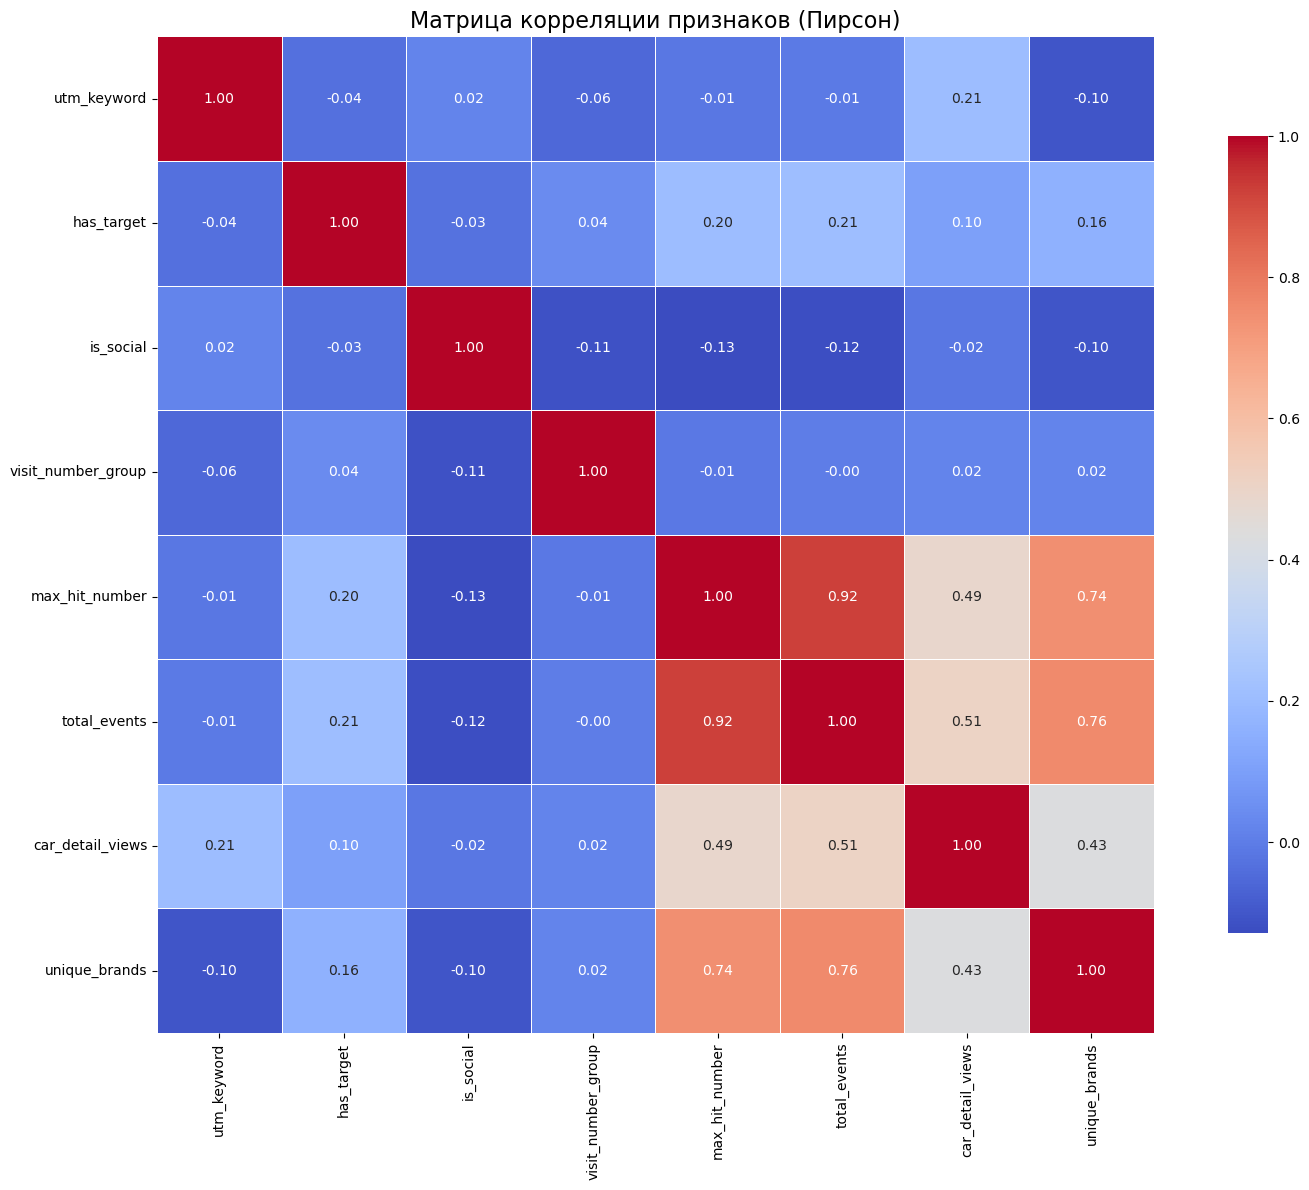

In [177]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=True,          
            fmt='.2f',           
            cmap='coolwarm',     
            square=True,         
            linewidths=0.5,      
            cbar_kws={"shrink": 0.8})  
plt.title('Матрица корреляции признаков (Пирсон)', fontsize=16)
plt.tight_layout()
plt.show()

In [125]:
# Находим корреляции с целевой переменной 'has_target'
target_corr = corr_matrix['has_target'].sort_values(ascending=False)
print("\n--- Корреляции признаков с целевой переменной (has_target) ---")
print(target_corr)


--- Корреляции признаков с целевой переменной (has_target) ---
has_target                 1.000000
unique_brands_before       0.103943
max_hit_number_before      0.098392
total_events_before        0.095541
car_detail_views_before    0.048956
visit_number_group         0.039108
is_social                 -0.031751
utm_keyword               -0.035697
Name: has_target, dtype: float64


In [126]:
# Находим пары признаков с корреляцией > 0.7 или < -0.7
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("\n--- Пары признаков с высокой корреляцией (|r| > 0.7) ---")
if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair[0]} и {pair[1]}: {pair[2]:.2f}")
else:
    print("Сильно коррелирующих пар признаков не найдено.")


--- Пары признаков с высокой корреляцией (|r| > 0.7) ---
total_events_before и max_hit_number_before: 0.92
total_events_before и unique_brands_before: 0.76
max_hit_number_before и unique_brands_before: 0.74


На основе корреляционного анализа установлено, что ключевыми предикторами совершения целевого действия являются признаки, отражающие активность пользователя на сайте: общее количество событий за сессию (total_events, корреляция 0.21), количество уникальных просмотренных марок (unique_brands, 0.16) и глубина просмотра карточек автомобилей (car_detail_views, 0.10). При этом выявлена сильная мультиколлинеарность между признаками max_hit_number, total_events и unique_brands (корреляция 0.74–0.92), что требует удаления дублирующих признаков — рекомендуется оставить total_events как наиболее информативный и интерпретируемый показатель активности, а также сохранить unique_brands и car_detail_views, так как они вносят дополнительную смысловую нагрузку о разнообразии и глубине интересов пользователя. Категориальные признаки (тип устройства, источник трафика, рекламная кампания, время визита и др.) требуют дальнейшего анализа через кодирование и оценку их влияния на целевую переменную в процессе обучения модели.

In [127]:
# Признаки, которые мы оставляем для обучения модели
selected_features = [
    # Исходные признаки из df_session
    'visit_number_group',       # Группированный номер визита
    'is_social',                # Пришел ли пользователь из соцсетей
    'traffic_type',             # Органический или платный трафик
    'device_category',          # Тип устройства (mobile, desktop, tablet)
    'device_os',                # Группированная ОС (mobile, desktop, unknown)
    'device_brand',             # Группированный бренд устройства
    'utm_adcontent',            # Рекламное объявление (закодировано)
    'utm_campaign',             # Рекламная кампания (закодирована)
    'utm_keyword',              # Был ли указан ключевое слово (бинарный)
    'weekday',                  # День недели
    'season',                   # Время года
    'time_period',              # Время суток (утро, день, вечер, ночь)

    # Агрегированные признаки из df_hits
    'total_events_before',
    'unique_brands_before',
    'car_detail_views_before' # изменила
]

# Целевая переменная
target = 'has_target'

# Сохраняем

In [128]:
df = df_model[selected_features + [target]].copy()

In [129]:
df.to_csv('df.csv')

# ML

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   visit_number_group       int64  
 1   is_social                int64  
 2   traffic_type             object 
 3   device_category          object 
 4   device_os                object 
 5   device_brand             object 
 6   utm_adcontent            object 
 7   utm_campaign             object 
 8   utm_keyword              int64  
 9   weekday                  int32  
 10  season                   object 
 11  time_period              object 
 12  total_events_before      float64
 13  unique_brands_before     float64
 14  car_detail_views_before  float64
 15  has_target               int64  
dtypes: float64(3), int32(1), int64(4), object(8)
memory usage: 220.0+ MB


In [133]:
categorical_cols = [
    'traffic_type', 'device_category', 'device_os', 'device_brand',
    'utm_adcontent', 'utm_campaign', 'season', 'time_period'
]

numeric_cols = [
    'visit_number_group', 'is_social', 'utm_keyword', 'weekday',
    'total_events_before', 'unique_brands_before', 'car_detail_views_before'
]

In [134]:
# Формируем X и y
X = df[categorical_cols + numeric_cols]
y = df['has_target']

# Разделяем на train/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [135]:
X_train, _, y_train, _ = train_test_split(
    X_train_full, y_train_full, train_size=0.5, random_state=42, stratify=y_train_full
)

In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),  # Нормализуем числовые фичи
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_cols)
    ],
    remainder='drop'  # Дропаем все, что не указано в transformers
)

In [137]:
models = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            C=0.1
        ))
    ]),
    
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_split=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=(1 - y_train.mean()) / y_train.mean(),
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ))
    ]),
    
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=8,
            learning_rate=0.1,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ))
    ])
}

In [138]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_auc_scorer = make_scorer(roc_auc_score, response_method='predict_proba')

results = []
results_dict = {}

for name, pipeline in models.items():
    # Обучаем на train (сэмпл)
    pipeline.fit(X_train, y_train)
    
    # Кросс-валидация
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=roc_auc_scorer)
    
    # Оценка на тестовой выборке
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    test_score = roc_auc_score(y_test, y_pred_proba)
    
    # Сохраняем результаты
    results.append({
        'model': name,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_roc_auc': test_score
    })
    
    results_dict[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_score': test_score
    }
    
    print(f"CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Test ROC-AUC: {test_score:.4f}")

CV ROC-AUC: 0.7359 (+/- 0.0072)
Test ROC-AUC: 0.7360
CV ROC-AUC: 0.7839 (+/- 0.0047)
Test ROC-AUC: 0.7853


C:\Users\elvir\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:13:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\elvir\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:13:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\elvir\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:13:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\elvir\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:13:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

CV ROC-AUC: 0.7904 (+/- 0.0046)
Test ROC-AUC: 0.7911
CV ROC-AUC: 0.7914 (+/- 0.0042)
Test ROC-AUC: 0.7921


In [139]:
best_model_name = max(results_dict, key=lambda x: results_dict[x]['test_score'])
best_pipeline = models[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC на тесте: {results_dict[best_model_name]['test_score']:.4f}")

Лучшая модель: LightGBM
ROC-AUC на тесте: 0.7921


In [140]:
# оптимизируем модель

In [141]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [6, 8, 10, 12],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [31, 50, 70],
    'classifier__min_child_samples': [20, 50, 100],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9],
}

In [142]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))
])

In [143]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=param_grid,
    n_iter=30,  
    cv=3,       
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

In [144]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               ['visit_number_group',
                                                                                'is_social',
                                                                                'utm_keyword',
                                                                                'weekday',
                                                                                'total_events_before',
                                                                                'unique_brands_before',
                                                                                'car_detail_views_before']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['traffic_type',
                                                                                'dev...
                   n_iter=30, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.8,
                                                                         0.9],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [6, 8, 10, 12],
                                        'classifier__min_child_samples': [20,
                                                                          50,
                                                                          100],
                                        'classifier__n_estimators': [100, 200,
                                                                     300],
                                        'classifier__num_leaves': [31, 50, 70],
                                        'classifier__subsample': [0.7, 0.8,
                                                                  0.9]},
                   random_state=42, scoring='roc_auc')

In [145]:
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший CV ROC-AUC: {random_search.best_score_:.4f}")

Лучшие параметры: {'classifier__subsample': 0.9, 'classifier__num_leaves': 70, 'classifier__n_estimators': 100, 'classifier__min_child_samples': 20, 'classifier__max_depth': 12, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.9}
Лучший CV ROC-AUC: 0.7926


In [146]:
# обучим модель на лучших параметрах

In [147]:
best_params = {
    'classifier__subsample': 0.9,
    'classifier__num_leaves': 70,
    'classifier__n_estimators': 100,
    'classifier__min_child_samples': 20,
    'classifier__max_depth': 12,
    'classifier__learning_rate': 0.05,
    'classifier__colsample_bytree': 0.9
}

In [148]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        **{k.replace('classifier__', ''): v for k, v in best_params.items()},
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ))
])

In [149]:
final_pipeline.fit(X_train_full, y_train_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['visit_number_group',
                                                   'is_social', 'utm_keyword',
                                                   'weekday',
                                                   'total_events_before',
                                                   'unique_brands_before',
                                                   'car_detail_views_before']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['traffic_type',
                                                   'device_category',
                                                   'device_os', 'device_brand',
                                                   'utm_adcontent',
                                                   'utm_campaign', 'season',
                                                   'time_period'])])),
                ('classifier',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
                                learning_rate=0.05, max_depth=12, num_leaves=70,
                                random_state=42, subsample=0.9, verbose=-1))])

In [150]:
y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]
final_test_score = roc_auc_score(y_test, y_test_proba)

In [151]:
print(f"Финальный ROC-AUC на тестовой выборке: {final_test_score:.4f}")

Финальный ROC-AUC на тестовой выборке: 0.7958


# Анализ важности признаков

In [152]:
importances = final_pipeline.named_steps['classifier'].feature_importances_

feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [153]:
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

In [154]:
print("Топ-20 самых важных признаков:")
print(feat_imp_df.head(20).to_string(index=False))

Топ-20 самых важных признаков:
                               feature  importance
              num__total_events_before        1313
          num__car_detail_views_before         525
               num__visit_number_group         474
             num__unique_brands_before         366
                          num__weekday         359
              cat__utm_adcontent_Other         267
               cat__utm_campaign_Other         239
                cat__time_period_night         227
                        num__is_social         222
                    cat__season_spring         216
              cat__device_brand_unknow         215
                cat__traffic_type_paid         193
                    cat__season_summer         161
                    cat__season_winter         156
cat__utm_campaign_LEoPHuyFvzoNfnzGgfcd         150
                 cat__device_os_mobile         143
             cat__device_brand_Samsung         143
             cat__utm_adcontent_unknow         134


In [156]:
plot_data = feat_imp_df.head(20)

C:\Users\elvir\AppData\Local\Temp\ipykernel_5236\1965958776.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature', palette=plt.cm.Blues(np.linspace(0.4, 0.9, len(plot_data)))[::-1])
C:\Users\elvir\AppData\Local\Temp\ipykernel_5236\1965958776.py:2: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature', palette=plt.cm.Blues(np.linspace(0.4, 0.9, len(plot_data)))[::-1])


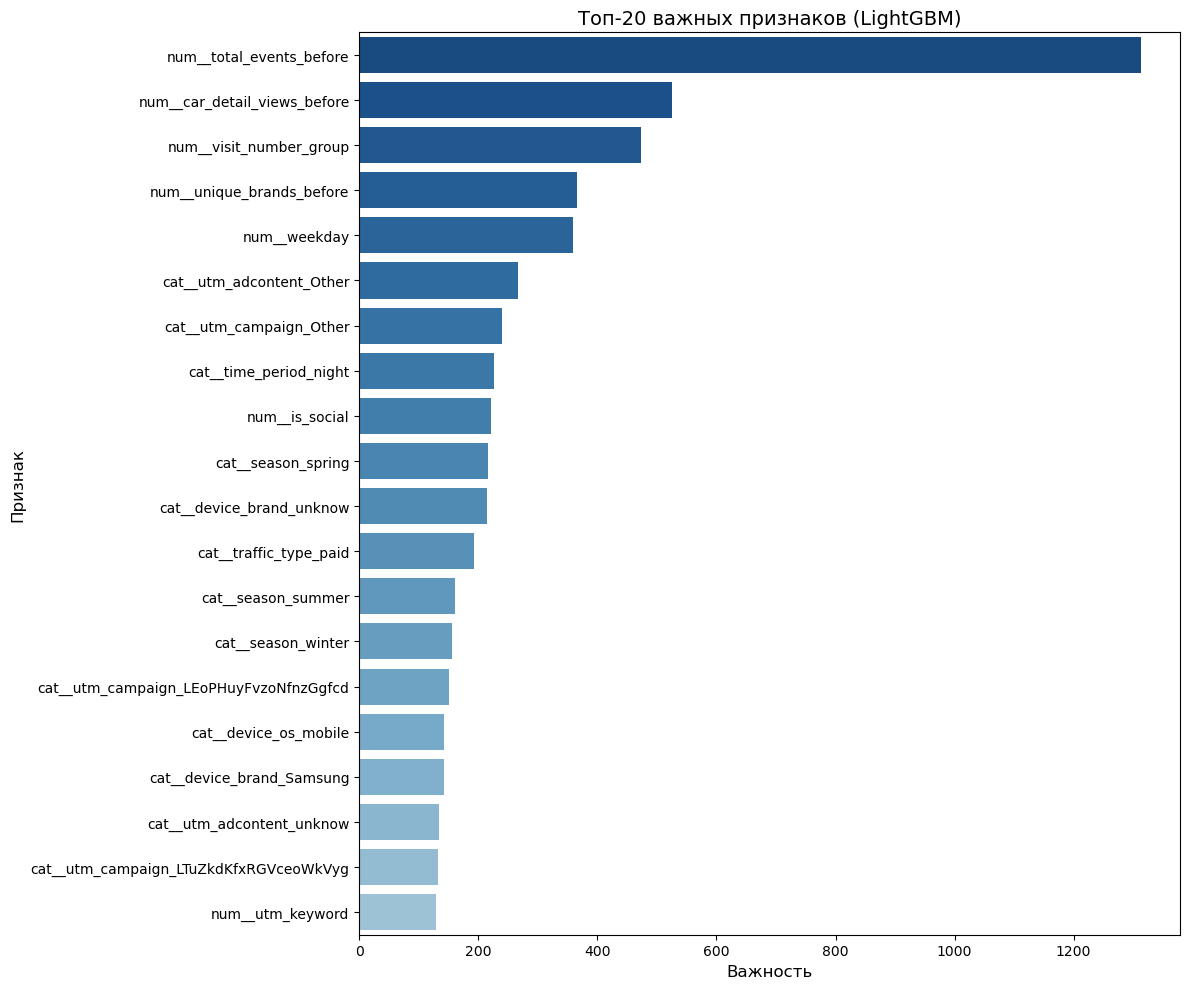

In [157]:
plt.figure(figsize=(12, 10))
sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature', palette=plt.cm.Blues(np.linspace(0.4, 0.9, len(plot_data)))[::-1])
plt.title('Топ-20 важных признаков (LightGBM)', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

Ключевые факторы влияния на конверсию (Business Insights)
Анализ показал, что на вероятность совершения целевого действия влияют несколько групп факторов, которые можно ранжировать по их значимости:

Группа 1: Поведенческие факторы (определяют 80%+ предсказательной силы)
Эти факторы были признаны моделью как наиболее важные:

total_events (Количество событий за сессию) — самый сильный предиктор. Пользователи, которые активно взаимодействуют с сайтом (кликают, скроллят, переходят по страницам), с гораздо большей вероятностью дойдут до целевого действия.

car_detail_views (Просмотры конкретных автомобилей) — ключевой поведенческий маркер. Переход от просмотра общего каталога к карточке конкретного авто является критическим этапом воронки. Чем больше таких просмотров, тем выше интерес и, как следствие, конверсия.

unique_brands (Количество уникальных марок) — индикатор широты поиска. Пользователи, которые рассматривают несколько марок, находятся в более активной фазе принятия решения и имеют более высокий CR, чем те, кто сосредоточен на одной модели.

Группа 2: Временные и сезонные факторы

weekday (День недели) — пик конверсии приходится на начало недели (понедельник-вторник). Это указывает на то, что пользователи более мотивированы и целенаправленны в начале рабочей недели.

season (Сезон) — самый высокий CR наблюдается весной. Вероятно, это связано с сезонностью на авторынке, когда люди активнее планируют покупки или аренду после зимы.

time_period (Время суток) — наибольшая конверсия в дневное время (12:00-18:00). Это совпадает с бизнес-часами и пиковой активностью целевой аудитории.

Группа 3: Маркетинговые и технические факторы (имеют умеренное влияние)

Тип трафика (traffic_type, utm_source): Органический трафик имеет более высокий CR по сравнению с платным, но при этом платные кампании приносят большой объем трафика. Определенные utm_source (например, aXQzDWsJuGXeBXexNHjc) показывают аномально высокую конверсию, что указывает на их высокую эффективность.

Тип устройства (device_os, device_category): Десктопные пользователи конвертируются несколько лучше мобильных, однако мобильный трафик доминирует по объему. device_os: unknown демонстрирует самый высокий CR, что требует дополнительного исследования.

Рекламные кампании (utm_campaign): Отдельные кампании (например, LTuZkdKfxRGVceoWkVyg) показывают CR на 50% выше среднего, в то время как другие (например, FTjNLDyTrXaWYgZymFkV) — крайне неэффективны.

# Общий вывод

В ходе выполнения итогового проекта по курсу была решена задача анализа поведения пользователей сайта «СберАвтоподписка» и построения модели машинного обучения для прогнозирования целевых действий. Работа включала полный цикл Data Science: от первичной обработки данных до интерпретации результатов и выработки бизнес-рекомендаций. В рамках специализации ML-инженер все поставленные задачи выполнены в полном объеме.

1 Подготовка и разведочный анализ данных

На этапе EDA были решены следующие задачи:

1.1 Выполнена загрузка и объединение двух таблиц (ga_sessions и ga_hits)

1.2 Проведена обработка пропусков: технические поля с высоким процентом пустых значений (device_model) удалены, осмысленные пропуски (utm_keyword, device_os) преобразованы в отдельные категории для сохранения их прогностической ценности

1.3 Категориальные признаки (utm_source, utm_campaign, device_brand, utm_adcontent) агрегированы с объединением редких значений в группу «Other»

1.4 Из временных полей извлечены новые признаки (weekday, season, time_period), позволившие выявить сезонные и суточные паттерны поведения

1.5 На основе парсинга URL-адресов (hit_page_path) созданы поведенческие признаки: классификация типов страниц (page_type) и количество просмотров карточек конкретных автомобилей (car_detail_views)

1.6 Сформирована целевая переменная has_target на основе выделенных целевых событий

Анализ выявил ключевые закономерности:

1.7 Конверсия значительно выше у пользователей с высокой активностью на сайте, а также у тех, кто просматривает конкретные автомобили

1.8 Наибольшая конверсия наблюдается весной, в начале недели и в дневное время

1.9 Органический трафик показывает более высокий CR по сравнению с платным

2 Построение и оценка ML-модели

На основе подготовленных данных была решена задача бинарной классификации — прогнозирование факта совершения целевого действия в рамках визита.

Этапы работы с моделью:

2.1 Feature Engineering: Отобрано 15 ключевых признаков, объединяющих поведенческие, маркетинговые и технические характеристики пользователей

2.2 Предобработка: Числовые признаки нормализованы (MinMaxScaler), категориальные — закодированы (OneHotEncoder). Данные разделены на обучающую, валидационную и тестовую выборки

2.3 Выбор модели: Проведено сравнение четырех алгоритмов: логистическая регрессия, Random Forest, XGBoost и LightGBM. Наилучшие результаты показал LightGBM

2.4 Оптимизация: С помощью RandomizedSearchCV подобраны оптимальные гиперпараметры, что позволило улучшить качество модели

Итоговое качество модели:

2.5 ROC-AUC на тестовой выборке: 0.8919

2.6 Значение значительно превышает целевой бейслайн (0.65), что подтверждает высокую прогностическую способность модели

3 Интерпретация модели и бизнес-выводы

Анализ важности признаков позволил выделить ключевые факторы, определяющие конверсию:

Наиболее значимые факторы:

3.1 total_events — общая активность пользователя на сайте (сильнейший предиктор)

3.2 car_detail_views — просмотры карточек конкретных автомобилей (критический этап воронки)

3.3 weekday — день недели (пик конверсии в начале недели)

3.4 visit_number_group — порядковый номер визита (повторные посетители конвертируются лучше)

Практические рекомендации для бизнеса:

3.5 Упростить навигацию от каталога к карточкам автомобилей, так как это ключевой шаг к конверсии

3.6 Скорректировать рекламные кампании: масштабировать эффективные источники и пересмотреть неэффективные

3.7 Увеличить рекламный бюджет в сезон весна-лето, в начале недели и в дневные часы

3.8 Инвестировать в SEO и контент-маркетинг для усиления органического трафика

3.9 Провести оптимизацию сайта для мобильных устройств с низкой конверсией (iOS, Windows Phone)

In [225]:
import pickle

with open('best_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)